In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft2, ifft2, fftshift
from tqdm import tqdm

# Shared plotting style aligned with the enlarged Cell 16 figures
PLOT_TITLE_FONTSIZE = 28
PLOT_LABEL_FONTSIZE_WIDE = 24
PLOT_LABEL_FONTSIZE_GRID = 22
PLOT_TICK_FONTSIZE_WIDE = 18
PLOT_TICK_FONTSIZE_GRID = 16
PLOT_LEGEND_FONTSIZE_WIDE = 20
PLOT_LEGEND_FONTSIZE_GRID = 18
PLOT_LINEWIDTH = 2.5

# Set random seed for reproducibility
np.random.seed(42)

def plot_field_2d(data, title, cmap='viridis'):
    """
    Helper function to plot 2D fields.
    """
    plt.figure(figsize=(6, 5))
    plt.imshow(data, cmap=cmap, origin='lower')
    cbar = plt.colorbar(label='u(x, y)')
    cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)
    plt.title(title, fontsize=PLOT_TITLE_FONTSIZE)
    plt.xlabel('x', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    plt.ylabel('y', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    plt.xticks(fontsize=PLOT_TICK_FONTSIZE_WIDE)
    plt.yticks(fontsize=PLOT_TICK_FONTSIZE_WIDE)
    plt.show()

def get_power_spectrum_2d(data):
    """
    Computes the azimuthally averaged power spectrum.
    Useful for checking if generative models capture the correct frequency content.
    """
    F = fftshift(fft2(data))
    psd = np.abs(F)**2
    return psd

## Allen-Cahn Equation (2D)
**Mathematical Form:**
$$ \frac{\partial u}{\partial t} = D \nabla^2 u - \frac{1}{\epsilon^2} u (u^2 - 1) $$

**Characteristics:**
This equation describes phase separation. The solution $u$ tends towards $+1$ or $-1$, forming "grains" separated by sharp interfaces.
*   **Target for GenAI:** Can the model generate sharp interfaces? Can it capture the coarsening rate (how grains grow over time)?

Simulating Stochastic Allen-Cahn (SPDE) for 25 steps...
  Noise intensity: sigma = 1.4142
  Epsilon: 0.01
  Reaction time scale: epsilon^2 = 0.0001
  dt = 2e-05


100%|██████████| 25/25 [00:00<00:00, 3572.42it/s]


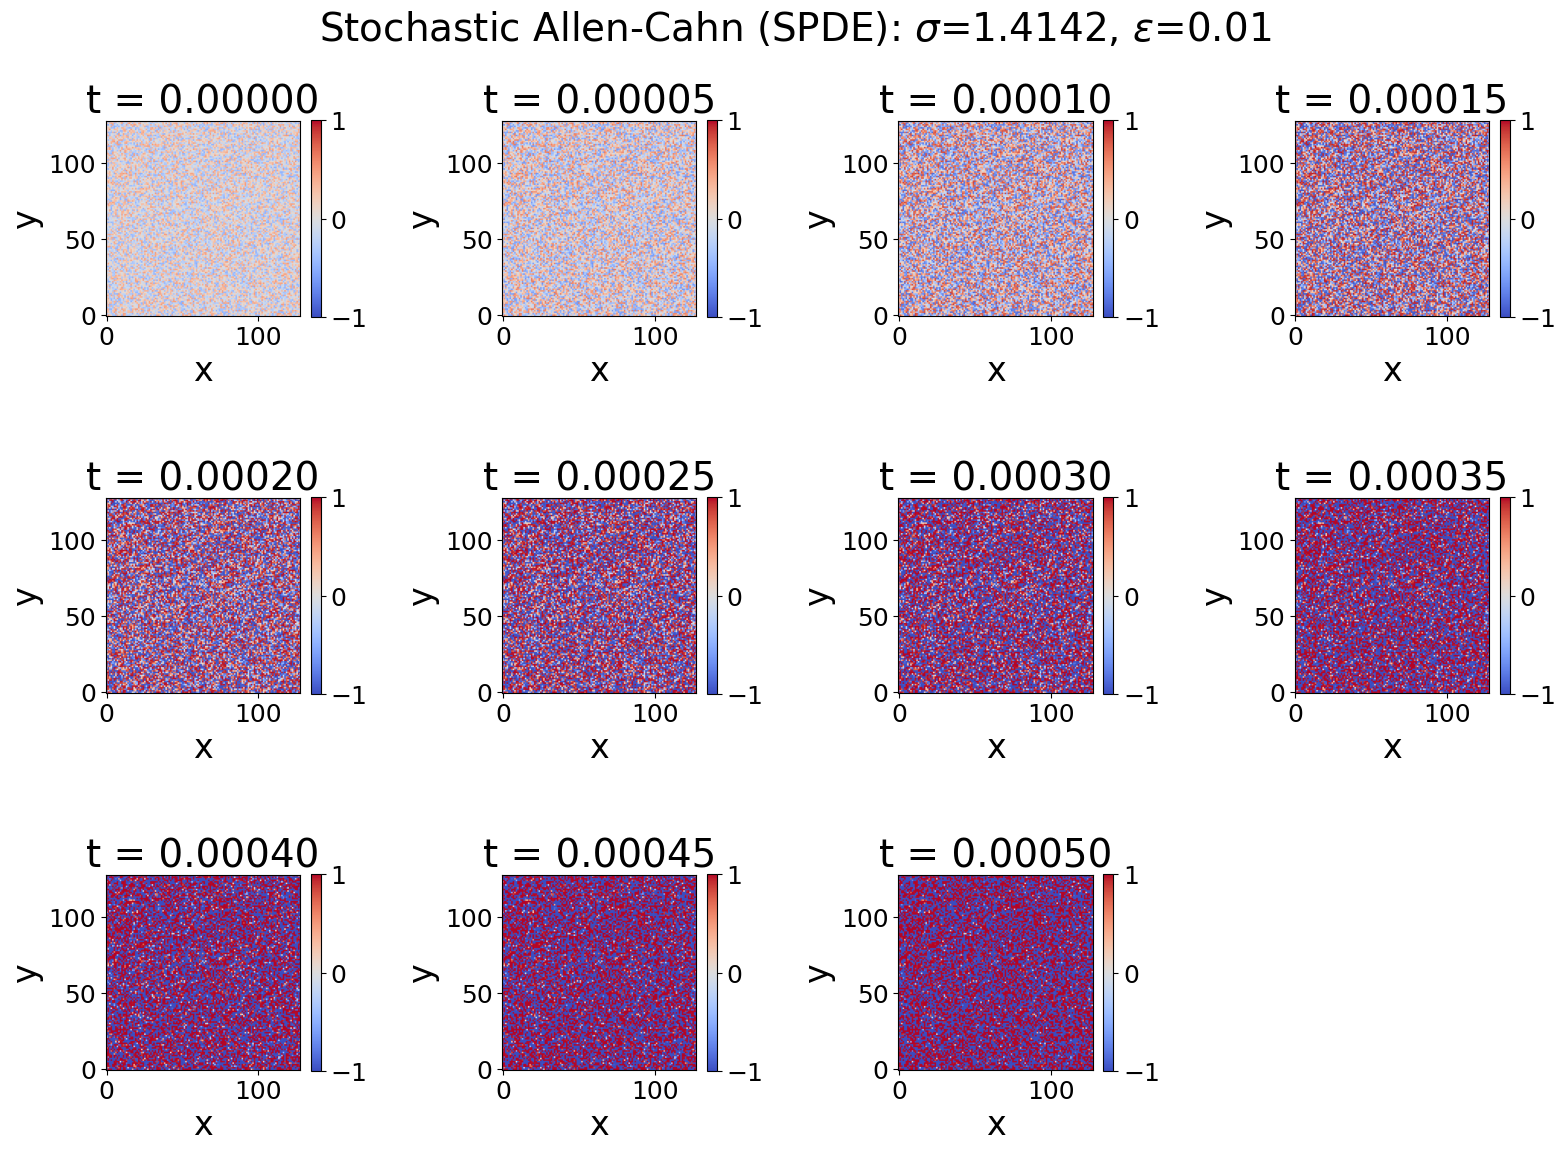

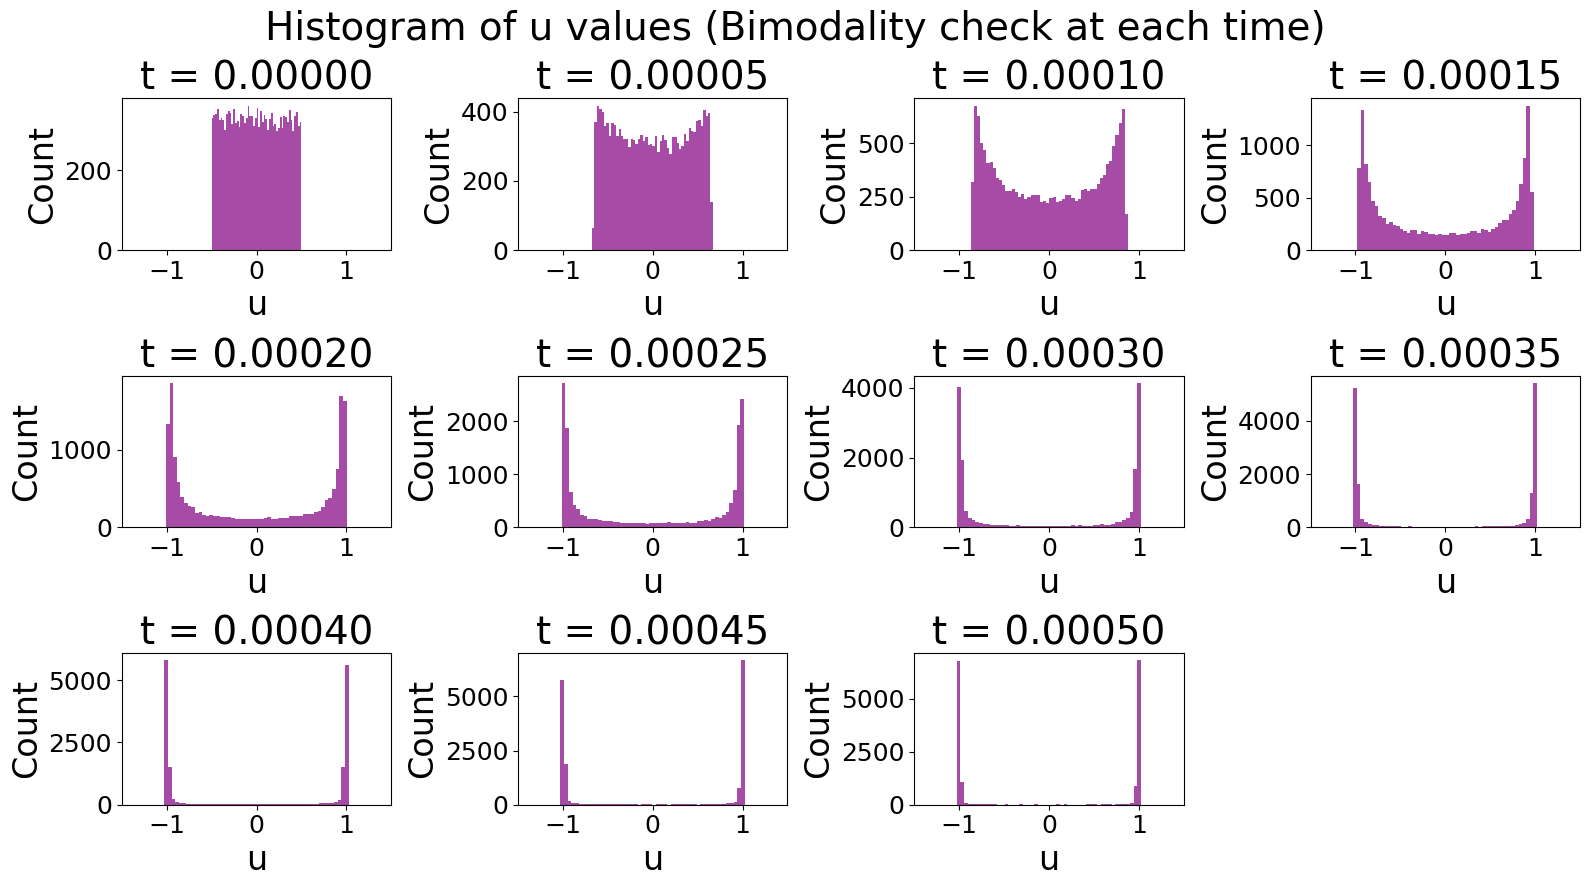

In [2]:
class StochasticAllenCahn2D:
    """
    Stochastic Allen-Cahn equation (SPDE) with additive noise:
    du/dt = D * Laplacian(u) - (1/eps^2) * u * (u^2 - 1) + sigma * dW
    
    where dW is the increment of a Wiener process (white noise).
    """
    def __init__(self, N=64, L=1.0, D=0.001, epsilon=0.01, sigma=0.1, dt=0.001):
        """
        N: Grid size (N x N)
        L: Physical domain size
        D: Diffusion coefficient
        epsilon: Interface width parameter
        sigma: Noise intensity (standard deviation per unit time)
        dt: Time step
        """
        self.N = N
        self.L = L
        self.D = D
        self.epsilon = epsilon
        self.sigma = sigma
        self.dt = dt
        self.dx = L / N
        
        # Noise scaling for Euler-Maruyama: sigma * sqrt(dt)
        self.noise_scale = sigma * np.sqrt(dt)
        
        # Initialize grid
        self.u = np.random.uniform(-0.5, 0.5, (N, N))
        
    def laplacian(self, u):
        """Finite difference approximation of Laplacian with Periodic BC"""
        u_top = np.roll(u, 1, axis=0)
        u_bottom = np.roll(u, -1, axis=0)
        u_left = np.roll(u, 1, axis=1)
        u_right = np.roll(u, -1, axis=1)
        return (u_top + u_bottom + u_left + u_right - 4*u) / (self.dx**2)

    def step(self):
        """Euler-Maruyama time stepping for SPDE"""
        # Deterministic part: reaction-diffusion
        reaction = -(1.0 / self.epsilon**2) * self.u * (self.u**2 - 1.0)
        diffusion = self.D * self.laplacian(self.u)
        
        # Stochastic part: additive white noise (Wiener increment)
        dW = self.noise_scale * np.random.randn(self.N, self.N)
        
        # Euler-Maruyama update
        self.u += self.dt * (diffusion + reaction) + dW

# Backward compatibility alias
AllenCahn2D = StochasticAllenCahn2D

# --- Simulation with snapshots at multiple time points ---
# sigma=1.4142 is sqrt(2) noise intensity
# Use smaller dt for epsilon=0.01 (reaction time scale ~ 0.0001)
ac_sim = StochasticAllenCahn2D(N=128, dt=2e-5, epsilon=0.01, sigma=1.4142)

# Define time points to capture: 0 to 0.0005, with 11 points (interval = 0.00005)
# For epsilon=0.01, reaction time scale ~ epsilon^2 = 0.0001
snapshot_times = np.linspace(0, 0.0005, 11)
snapshot_steps = set([int(round(t / ac_sim.dt)) for t in snapshot_times])  # Use round for numerical safety
total_steps = max(snapshot_steps)  # Only simulate as long as needed

snapshots = {}

# Save initial state (t=0)
snapshots[0] = ac_sim.u.copy()

print(f"Simulating Stochastic Allen-Cahn (SPDE) for {total_steps} steps...")
print(f"  Noise intensity: sigma = {ac_sim.sigma}")
print(f"  Epsilon: {ac_sim.epsilon}")
print(f"  Reaction time scale: epsilon^2 = {ac_sim.epsilon**2}")
print(f"  dt = {ac_sim.dt}")

for step in tqdm(range(1, total_steps + 1)):
    ac_sim.step()
    if step in snapshot_steps:
        snapshots[step] = ac_sim.u.copy()

# --- Visualization: Multiple time snapshots ---
n_snapshots = len(snapshot_times)
n_cols = 4
n_rows = (n_snapshots + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for idx, t_phys in enumerate(snapshot_times):
    step_num = int(round(t_phys / ac_sim.dt))
    ax = axes[idx]
    im = ax.imshow(snapshots[step_num], cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    ax.set_title(f't = {t_phys:.5f}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_ylabel('y', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)

# Hide unused subplots
for idx in range(n_snapshots, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Stochastic Allen-Cahn (SPDE): $\\sigma$={ac_sim.sigma}, $\\epsilon$={ac_sim.epsilon}', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

# --- Histogram visualization for each time snapshot ---
fig2, axes2 = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes2 = axes2.flatten()

for idx, t_phys in enumerate(snapshot_times):
    step_num = int(round(t_phys / ac_sim.dt))
    ax = axes2[idx]
    ax.hist(snapshots[step_num].flatten(), bins=50, color='purple', alpha=0.7)
    ax.set_title(f't = {t_phys:.5f}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_ylabel('Count', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_xlim(-1.5, 1.5)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)

# Hide unused subplots
for idx in range(n_snapshots, len(axes2)):
    axes2[idx].axis('off')

plt.suptitle('Histogram of u values (Bimodality check at each time)', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

## KSWGD Analysis: Learning the Distribution at Different Time Steps

We will use the **KSWGD (Koopman Spectral Wasserstein Gradient Descent)** method to:
1. Learn the distribution of spatial patterns at each time snapshot
2. Generate new samples from the learned distribution
3. Observe if the generated distribution captures the **bimodal structure** (Î´-like peaks at Â±1)

**Pipeline:**
- Each snapshot is a 128Ã—128 = 16384-dimensional vector
- Use Autoencoder to reduce to a low-dimensional latent space
- Apply EDMD + KSWGD in latent space
- Decode back and visualize the distribution

In [3]:
# === Setup for KSWGD ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import PolynomialFeatures
from scipy.linalg import eig
from tqdm.auto import trange
import warnings
warnings.filterwarnings("ignore")

# Import KSWGD kernel functions
from grad_ker1 import grad_ker1
from K_tar_eval import K_tar_eval

# Try to import GPU versions
try:
    import cupy as cp
    from grad_ker1_gpu import grad_ker1 as grad_ker1_gpu
    from K_tar_eval_gpu import K_tar_eval as K_tar_eval_gpu
    KSWGD_GPU_AVAILABLE = True
except Exception:
    cp = None
    grad_ker1_gpu = None
    K_tar_eval_gpu = None
    KSWGD_GPU_AVAILABLE = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_gpu_kswgd = bool(KSWGD_GPU_AVAILABLE and torch.cuda.is_available())

print(f"Using device: {device}")
print(f"KSWGD GPU backend: {'enabled' if use_gpu_kswgd else 'disabled'}")

Using device: cuda
KSWGD GPU backend: enabled


In [4]:
# === Autoencoder for Allen-Cahn spatial patterns ===
# Input: 128x128 = 16384 dimensional vectors
# Latent: 8-16 dimensions (tunable)

class ACEncoder(nn.Module):
    """Encoder for Allen-Cahn 2D fields"""
    def __init__(self, input_size=128, latent_dim=8):
        super().__init__()
        self.input_size = input_size
        flat_size = input_size * input_size
        
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim),
        )
    
    def forward(self, x):
        return self.net(x)

class ACDecoder(nn.Module):
    """Decoder for Allen-Cahn 2D fields"""
    def __init__(self, input_size=128, latent_dim=8):
        super().__init__()
        self.input_size = input_size
        flat_size = input_size * input_size
        
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 512),
            nn.ReLU(),
            nn.Linear(512, flat_size),
            nn.Tanh(),  # Output in [-1, 1] range for Allen-Cahn
        )
    
    def forward(self, z):
        x_flat = self.net(z)
        return x_flat.view(-1, self.input_size, self.input_size)

class ACAutoencoder(nn.Module):
    """Autoencoder for Allen-Cahn 2D fields"""
    def __init__(self, input_size=128, latent_dim=8):
        super().__init__()
        self.encoder = ACEncoder(input_size, latent_dim)
        self.decoder = ACDecoder(input_size, latent_dim)
        self.latent_dim = latent_dim
    
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

print("Autoencoder architecture defined.")

Autoencoder architecture defined.


In [5]:
# === KSWGD Function for Allen-Cahn ===
# 
# TRUE TIME EVOLUTION VERSION:
# 1. Generate time series data: t=0, t=dt, t=2dt, ...
# 2. Use ONLY t=0 → t=dt pairs to build Koopman operator
# 3. Use Koopman to PREDICT distributions at future times
# 4. Compare predictions with ground truth

def generate_ac_time_series_ensemble(n_samples=200, N=128, dt_sim=1e-4, epsilon=0.02, 
                                      sigma=0.1, time_points=[0, 0.0002, 0.0005, 0.001], verbose=True):
    """
    Generate an ensemble of Stochastic Allen-Cahn (SPDE) time series from different initial conditions.
    Each simulation is saved at multiple time points.
    
    Args:
        n_samples: Number of independent simulations
        N: Grid size
        dt_sim: Simulation time step
        epsilon: Interface width parameter
        sigma: Noise intensity for SPDE
        time_points: List of times to save snapshots
        
    Returns:
        dict: {time: np.array of shape (n_samples, N, N)} for each time point
    """
    if verbose:
        print(f"  Generating {n_samples} independent Stochastic AC (SPDE) time series...")
        print(f"  Noise intensity: sigma = {sigma}")
        print(f"  Time points: {time_points}")
    
    # Convert time points to step numbers
    time_steps = {t: int(t / dt_sim) for t in time_points}
    max_steps = max(time_steps.values())
    
    # Initialize output dictionary
    ensemble = {t: [] for t in time_points}
    
    for i in tqdm(range(n_samples), desc="Ensemble generation", disable=not verbose):
        # Create new SPDE simulation with fresh random IC
        ac = StochasticAllenCahn2D(N=N, dt=dt_sim, epsilon=epsilon, sigma=sigma)
        ac.u = np.random.uniform(-0.5, 0.5, (N, N))
        
        current_step = 0
        
        # Save t=0 if needed
        if 0 in time_steps.values():
            for t, step in time_steps.items():
                if step == 0:
                    ensemble[t].append(ac.u.copy())
        
        # Evolve and save at target times
        for step in range(1, max_steps + 1):
            ac.step()
            current_step = step
            
            # Check if we need to save at this step
            for t, target_step in time_steps.items():
                if step == target_step and target_step > 0:
                    ensemble[t].append(ac.u.copy())
    
    # Convert to numpy arrays
    ensemble = {t: np.array(snapshots) for t, snapshots in ensemble.items()}
    
    if verbose:
        for t, data in ensemble.items():
            print(f"    t={t}: shape {data.shape}")
    
    return ensemble


def train_autoencoder_on_data(data_flat, N, latent_dim, n_epochs, verbose=True):
    """Train autoencoder on flattened data."""
    # Scale to [-1, 1]
    data_min = data_flat.min()
    data_max = data_flat.max()
    data_range = data_max - data_min + 1e-8
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    
    train_tensor = torch.FloatTensor(data_scaled).to(device)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True)
    
    ae = ACAutoencoder(input_size=N, latent_dim=latent_dim).to(device)
    optimizer = optim.Adam(ae.parameters(), lr=1e-3)
    
    for epoch in range(n_epochs):
        total_loss = 0
        for (batch,) in train_loader:
            batch = batch.view(-1, N, N)
            optimizer.zero_grad()
            recon, z = ae(batch)
            loss = nn.MSELoss()(recon, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        
        if verbose and (epoch + 1) % 25 == 0:
            print(f"    Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.6f}")
    
    return ae, data_min, data_max


def run_kswgd_time_evolution(time_series_ensemble, latent_dim=8, poly_order=5,
                              m_particles=100, num_iters_kswgd=500, step_size_kswgd=0.1,
                              n_epochs_ae=100, verbose=True):
    """
    Run KSWGD with TRUE TIME EVOLUTION using Koopman operator.
    
    KEY DIFFERENCE from previous version:
    - Koopman operator is built from t=0 → t=dt data ONLY
    - Future time distributions are PREDICTED using repeated Koopman applications
    - We compare predictions vs ground truth at each future time
    
    Args:
        time_series_ensemble: dict {time: (n_samples, N, N)} from generate_ac_time_series_ensemble
        
    Returns:
        dict with predictions and ground truth at each time
    """
    time_points = sorted(time_series_ensemble.keys())
    if len(time_points) < 2:
        raise ValueError("Need at least 2 time points for time evolution")
    
    t0 = time_points[0]  # Initial time (usually 0)
    t1 = time_points[1]  # First time step (for building Koopman)
    dt_koopman = t1 - t0  # Time step for Koopman operator
    
    data_t0 = time_series_ensemble[t0]
    data_t1 = time_series_ensemble[t1]
    n_samples, N, _ = data_t0.shape
    
    if verbose:
        print(f"\n  === TRUE KOOPMAN TIME EVOLUTION ===")
        print(f"  Building Koopman from t={t0} → t={t1} (dt={dt_koopman})")
        print(f"  Will PREDICT distributions at t={time_points[2:]} using this operator")
        print(f"  Ensemble size: {n_samples}")
    
    # ============================================================
    # Step 1: Train Autoencoder on ALL time point data (for fair encoding)
    # ============================================================
    if verbose:
        print(f"\n  Training Autoencoder on all time data...")
    
    all_data = np.concatenate([time_series_ensemble[t] for t in time_points], axis=0)
    all_data_flat = all_data.reshape(-1, N*N)
    
    ae, data_min, data_max = train_autoencoder_on_data(
        all_data_flat, N, latent_dim, n_epochs_ae, verbose
    )
    data_range = data_max - data_min + 1e-8
    
    # ============================================================
    # Step 2: Encode t=0 and t=dt data to latent space
    # ============================================================
    ae.eval()
    
    def encode_data(data_3d):
        data_flat = data_3d.reshape(-1, N*N)
        data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
        with torch.no_grad():
            tensor = torch.FloatTensor(data_scaled).to(device).view(-1, N, N)
            z = ae.encoder(tensor).cpu().numpy()
        return z.astype(np.float64)
    
    Z_t0 = encode_data(data_t0)  # Latent codes at t=0
    Z_t1 = encode_data(data_t1)  # Latent codes at t=dt
    
    if verbose:
        print(f"  Latent codes: Z_t0 {Z_t0.shape}, Z_t1 {Z_t1.shape}")
    
    # ============================================================
    # Step 3: Build EDMD Koopman Operator from (t0, t1) pairs
    # This is the KEY: we use PAIRED data (same IC at different times)
    # ============================================================
    if verbose:
        print(f"\n  Building EDMD Koopman operator (poly_order={poly_order})...")
    
    poly = PolynomialFeatures(degree=poly_order, include_bias=True)
    Phi_X = poly.fit_transform(Z_t0)  # Features at t=0
    Phi_Y = poly.transform(Z_t1)       # Features at t=dt
    n_features = Phi_X.shape[1]
    
    if verbose:
        print(f"    Polynomial features: {n_features}")
    
    # EDMD: K such that Phi_Y ≈ Phi_X @ K
    reg_edmd = 1e-4
    G_edmd = (Phi_X.T @ Phi_X) / n_samples + reg_edmd * np.eye(n_features)
    A_edmd = (Phi_X.T @ Phi_Y) / n_samples
    K_edmd = np.linalg.solve(G_edmd, A_edmd)  # Koopman operator in feature space
    
    if verbose:
        print(f"    Koopman operator K shape: {K_edmd.shape}")
    
    # ============================================================
    # Step 4: Build KSWGD operators from t=0 data (target distribution)
    # ============================================================
    if verbose:
        print(f"\n  Building KSWGD operators from t=0 distribution...")
    
    Z_tar = Z_t0
    sq_tar = np.sum(Z_tar ** 2, axis=1)
    
    kswgd_dists = pairwise_distances(Z_tar, metric="euclidean")
    eps_kswgd = np.median(kswgd_dists**2) / (2.0 * np.log(Z_tar.shape[0] + 1))
    eps_kswgd = float(max(eps_kswgd, 1e-6))
    
    data_kernel = np.exp(-kswgd_dists**2 / (2.0 * eps_kswgd))
    p_x = np.sqrt(np.sum(data_kernel, axis=1))
    data_kernel_norm = data_kernel / (p_x[:, None] * p_x[None, :] + 1e-12)
    
    D_y = np.sum(data_kernel_norm, axis=0)
    rw_kernel = 0.5 * (data_kernel_norm / (D_y + 1e-12) + data_kernel_norm / (D_y[:, None] + 1e-12))
    rw_kernel = np.nan_to_num(rw_kernel)
    
    lambda_ns_kernel, phi_kernel = np.linalg.eigh(rw_kernel)
    phi_kernel = np.real(phi_kernel[:, ::-1])
    lambda_ns_kernel = np.real(lambda_ns_kernel[::-1])
    
    tol_kswgd = 1e-6
    mask_kswgd = lambda_ns_kernel >= tol_kswgd
    above_tol = int(np.sum(mask_kswgd))
    phi_trunc_kswgd = phi_kernel[:, :above_tol]
    
    lambda_gen_kernel = lambda_ns_kernel - 1.0
    inv_lambda = np.zeros_like(lambda_gen_kernel)
    inv_lambda[1:] = 1.0 / np.clip(np.abs(lambda_gen_kernel[1:]), 1e-12, None)
    inv_lambda *= eps_kswgd
    
    lambda_ns_inv = np.zeros_like(lambda_ns_kernel)
    lambda_ns_inv[mask_kswgd] = eps_kswgd / (lambda_ns_kernel[mask_kswgd] + 1e-3)
    lambda_ns_s_ns_kswgd = (lambda_ns_inv * inv_lambda * lambda_ns_inv)[:above_tol]
    
    p_tar = np.sum(data_kernel, axis=0)
    sqrt_p = np.sqrt(p_tar + 1e-12)
    D_vec = np.sum(data_kernel / sqrt_p[:, None] / sqrt_p[None, :], axis=1)
    
    if verbose:
        print(f"    Using {above_tol} kernel eigenfunctions")
    
    # ============================================================
    # Step 5: KSWGD to sample from t=0 distribution
    # ============================================================
    if verbose:
        print(f"\n  Running KSWGD to sample t=0 distribution...")
    
    rng_kswgd = np.random.default_rng(42)
    grad_fn = grad_ker1_gpu if use_gpu_kswgd else grad_ker1
    K_eval_fn = K_tar_eval_gpu if use_gpu_kswgd else K_tar_eval
    xp = cp if use_gpu_kswgd else np
    
    # Initialize from scaled Gaussian
    z_std = np.std(Z_t0, axis=0)
    z_mean = np.mean(Z_t0, axis=0)
    init_particles = rng_kswgd.normal(0.0, 1.0, size=(m_particles, latent_dim)) * z_std + z_mean
    
    if use_gpu_kswgd:
        Z_tar_dev = cp.asarray(Z_tar)
        p_tar_dev = cp.asarray(p_tar)
        sq_tar_dev = cp.asarray(sq_tar)
        D_vec_dev = cp.asarray(D_vec)
        phi_trunc_dev = cp.asarray(phi_trunc_kswgd)
        lambda_ns_s_ns_dev = cp.asarray(lambda_ns_s_ns_kswgd)
        z_hist = cp.zeros((m_particles, latent_dim, num_iters_kswgd), dtype=cp.float64)
        z_hist[:, :, 0] = cp.asarray(init_particles, dtype=cp.float64)
    else:
        Z_tar_dev = Z_tar
        p_tar_dev = p_tar
        sq_tar_dev = sq_tar
        D_vec_dev = D_vec
        phi_trunc_dev = phi_trunc_kswgd
        lambda_ns_s_ns_dev = lambda_ns_s_ns_kswgd
        z_hist = np.zeros((m_particles, latent_dim, num_iters_kswgd), dtype=np.float64)
        z_hist[:, :, 0] = init_particles
    
    for t in range(num_iters_kswgd - 1):
        grad_matrix = grad_fn(z_hist[:, :, t], Z_tar_dev, p_tar_dev, sq_tar_dev, D_vec_dev, eps_kswgd)
        cross_matrix = K_eval_fn(Z_tar_dev, z_hist[:, :, t], p_tar_dev, sq_tar_dev, D_vec_dev, eps_kswgd)
        
        tmp = phi_trunc_dev.T @ cross_matrix
        tmp = lambda_ns_s_ns_dev[:, None] * tmp
        kswgd_push = phi_trunc_dev @ tmp
        
        for d in range(latent_dim):
            sum_term = grad_matrix[:, :, d] @ kswgd_push
            z_hist[:, d, t + 1] = z_hist[:, d, t] - (step_size_kswgd / m_particles) * xp.sum(sum_term, axis=1)
    
    # Particles at t=0 (from KSWGD)
    if use_gpu_kswgd:
        Z_particles_t0 = cp.asnumpy(z_hist[:, :, -1])
    else:
        Z_particles_t0 = z_hist[:, :, -1]
    
    if verbose:
        print(f"    Generated {m_particles} particles at t=0")
    
    # ============================================================
    # Step 6: Use Koopman to PREDICT future time distributions
    # ============================================================
    if verbose:
        print(f"\n  === KOOPMAN TIME EVOLUTION ===")
        print(f"  Predicting future distributions using Koopman operator...")
    
    results = {}
    
    # Store t=0 results
    results[t0] = {
        'predicted_latent': Z_particles_t0,
        'ground_truth_latent': Z_t0,
    }
    
    # Current particles in latent space
    Z_current = Z_particles_t0.copy()
    
    for i, t_target in enumerate(time_points[1:], 1):
        # Number of Koopman steps needed: t_target / dt_koopman
        # Use int() to truncate (e.g., 0.0005/0.0002=2.5 → 2 steps)
        n_koopman_steps = int(t_target / dt_koopman)
        
        if verbose:
            print(f"\n    t = {t_target}: applying Koopman {n_koopman_steps} time(s) (K^{n_koopman_steps} ≈ t={n_koopman_steps * dt_koopman})")
        
        # Apply Koopman operator n_koopman_steps times starting from t=0
        Z_pred = Z_particles_t0.copy()
        
        # Compute bounds for stability clipping based on training data
        z_bounds = np.max(np.abs(Z_t0)) * 5.0  # Allow 5x the observed range
        
        for step in range(n_koopman_steps):
            # Transform to feature space
            Phi_pred = poly.transform(Z_pred)
            # Apply Koopman
            Phi_next = Phi_pred @ K_edmd
            # Extract latent coordinates (first latent_dim features after bias)
            # Note: PolynomialFeatures with include_bias=True puts bias first,
            # then degree-1 terms (which are the original coordinates)
            Z_pred = Phi_next[:, 1:latent_dim+1]
            
            # Numerical stability: clip to prevent explosion
            Z_pred = np.clip(Z_pred, -z_bounds, z_bounds)
            
            # Check for NaN and replace with mean if needed
            if np.any(np.isnan(Z_pred)):
                if verbose:
                    print(f"        Warning: NaN detected at step {step+1}, using fallback")
                Z_pred = np.nan_to_num(Z_pred, nan=0.0)
        
        # Get ground truth at this time
        Z_gt = encode_data(time_series_ensemble[t_target])
        
        results[t_target] = {
            'predicted_latent': Z_pred,
            'ground_truth_latent': Z_gt,
            'n_koopman_steps': n_koopman_steps,
        }
        
        if verbose:
            print(f"      Predicted latent mean: {Z_pred.mean(axis=0)[:3]}...")
            print(f"      Ground truth mean:     {Z_gt.mean(axis=0)[:3]}...")
    
    # ============================================================
    # Step 7: Decode all predictions and ground truths
    # ============================================================
    if verbose:
        print(f"\n  Decoding predictions to original space...")
    
    def decode_latent(z_latent):
        with torch.no_grad():
            z_tensor = torch.FloatTensor(z_latent).to(device)
            decoded = ae.decoder(z_tensor).cpu().numpy()
        # Rescale back
        samples = (decoded.reshape(-1, N*N) + 1.0) / 2.0 * data_range + data_min
        return samples.reshape(-1, N, N)
    
    for t in time_points:
        results[t]['predicted_samples'] = decode_latent(results[t]['predicted_latent'])
        results[t]['ground_truth_samples'] = time_series_ensemble[t]
    
    results['meta'] = {
        'time_points': time_points,
        'dt_koopman': dt_koopman,
        'ae': ae,
        'K_edmd': K_edmd,
        'poly': poly,
    }
    
    if verbose:
        print(f"\n  Time evolution complete!")
    
    return results

print("KSWGD functions defined (TRUE TIME EVOLUTION version).")
print("\nKey difference from previous version:")
print("  - Koopman operator is built from t=0 → t=dt data ONLY")
print("  - Future distributions are PREDICTED (not fitted)")
print("  - This tests Koopman's predictive ability!")

KSWGD functions defined (TRUE TIME EVOLUTION version).

Key difference from previous version:
  - Koopman operator is built from t=0 → t=dt data ONLY
  - Future distributions are PREDICTED (not fitted)
  - This tests Koopman's predictive ability!


In [6]:
# === Run TRUE TIME EVOLUTION with Koopman Operator ===
#
# This version:
# 1. Builds Koopman operator from t=0 → t=dt pairs ONLY
# 2. Uses Koopman to PREDICT future distributions
# 3. Compares predictions with ground truth

# === FIX RANDOM SEEDS FOR REPRODUCIBILITY ===
RANDOM_SEED = 5
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
print(f"Random seeds set to {RANDOM_SEED} for reproducibility")

# Define time points
# For epsilon=0.01: reaction time scale ~ epsilon^2 = 0.0001
# We need time points within a few reaction time scales for Koopman to work well
# t=0 is initial, t=0.0001 is used to build Koopman, later times are PREDICTED
time_points = [0, 0.0001, 0.0002, 0.0005]  # K^1, K^2, K^5

# SPDE parameters
EPSILON_PDE = 0.01   # Interface width parameter (smaller = sharper interface)
SIGMA_NOISE = 1.4142  # Noise intensity (sqrt(2) for comparable noise level)

print("="*70)
print("TRUE KOOPMAN TIME EVOLUTION for Stochastic Allen-Cahn (SPDE)")
print("="*70)
print(f"\nEpsilon (interface width): {EPSILON_PDE}")
print(f"Reaction time scale: epsilon^2 = {EPSILON_PDE**2}")
print(f"Noise intensity: sigma = {SIGMA_NOISE}")
print(f"Time points: {time_points}")
print(f"  - t={time_points[0]} → t={time_points[1]}: Used to BUILD Koopman operator")
print(f"  - t={time_points[2:]}: PREDICTED using Koopman (not used in training!)")
print()

# Step 1: Generate time series ensemble
print("Step 1: Generating SPDE time series ensemble...")
time_series_ensemble = generate_ac_time_series_ensemble(
    n_samples=500,  # More samples for better EDMD stability
    N=128,
    dt_sim=2e-5,    # Smaller time step for numerical accuracy (5x smaller than before)
    epsilon=EPSILON_PDE,  # Interface width parameter
    sigma=SIGMA_NOISE,    # Noise intensity
    time_points=time_points,
    verbose=True
)

# Print statistics at each time
print("\nEnsemble statistics at each time:")
for t, data in time_series_ensemble.items():
    print(f"  t={t}: mean={data.mean():.4f}, std={data.std():.4f}, "
          f"min={data.min():.4f}, max={data.max():.4f}")

# Step 2: Run KSWGD with true time evolution
print("\n" + "="*70)
print("Step 2: Running KSWGD with Koopman Time Evolution")
print("="*70)

kswgd_time_results = run_kswgd_time_evolution(
    time_series_ensemble,
    latent_dim=16,       # Increased from 8 for better representation
    poly_order=2,        # Keep low to prevent explosion
    m_particles=150,     # More particles
    num_iters_kswgd=800, # More iterations for convergence
    step_size_kswgd=0.03, # Smaller step for stability
    n_epochs_ae=150,     # More AE training epochs
    verbose=True
)

print("\n" + "="*70)
print("Koopman time evolution complete!")
print("="*70)

Random seeds set to 5 for reproducibility
TRUE KOOPMAN TIME EVOLUTION for Stochastic Allen-Cahn (SPDE)

Epsilon (interface width): 0.01
Reaction time scale: epsilon^2 = 0.0001
Noise intensity: sigma = 1.4142
Time points: [0, 0.0001, 0.0002, 0.0005]
  - t=0 → t=0.0001: Used to BUILD Koopman operator
  - t=[0.0002, 0.0005]: PREDICTED using Koopman (not used in training!)

Step 1: Generating SPDE time series ensemble...
  Generating 500 independent Stochastic AC (SPDE) time series...
  Noise intensity: sigma = 1.4142
  Time points: [0, 0.0001, 0.0002, 0.0005]


Ensemble generation: 100%|██████████| 500/500 [00:03<00:00, 163.66it/s]


    t=0: shape (500, 128, 128)
    t=0.0001: shape (500, 128, 128)
    t=0.0002: shape (500, 128, 128)
    t=0.0005: shape (500, 128, 128)

Ensemble statistics at each time:
  t=0: mean=-0.0001, std=0.2887, min=-0.5000, max=0.5000
  t=0.0001: mean=-0.0003, std=0.5664, min=-0.8923, max=0.8939
  t=0.0002: mean=-0.0005, std=0.8027, min=-1.0158, max=1.0163
  t=0.0005: mean=-0.0007, std=0.9840, min=-1.0353, max=1.0379

Step 2: Running KSWGD with Koopman Time Evolution

  === TRUE KOOPMAN TIME EVOLUTION ===
  Building Koopman from t=0 → t=0.0001 (dt=0.0001)
  Will PREDICT distributions at t=[0.0002, 0.0005] using this operator
  Ensemble size: 500

  Training Autoencoder on all time data...
    Epoch 25/150, Loss: 0.058750
    Epoch 50/150, Loss: 0.032725
    Epoch 75/150, Loss: 0.033188
    Epoch 100/150, Loss: 0.021384
    Epoch 125/150, Loss: 0.030014
    Epoch 150/150, Loss: 0.017284
  Latent codes: Z_t0 (500, 16), Z_t1 (500, 16)

  Building EDMD Koopman operator (poly_order=2)...
    Po

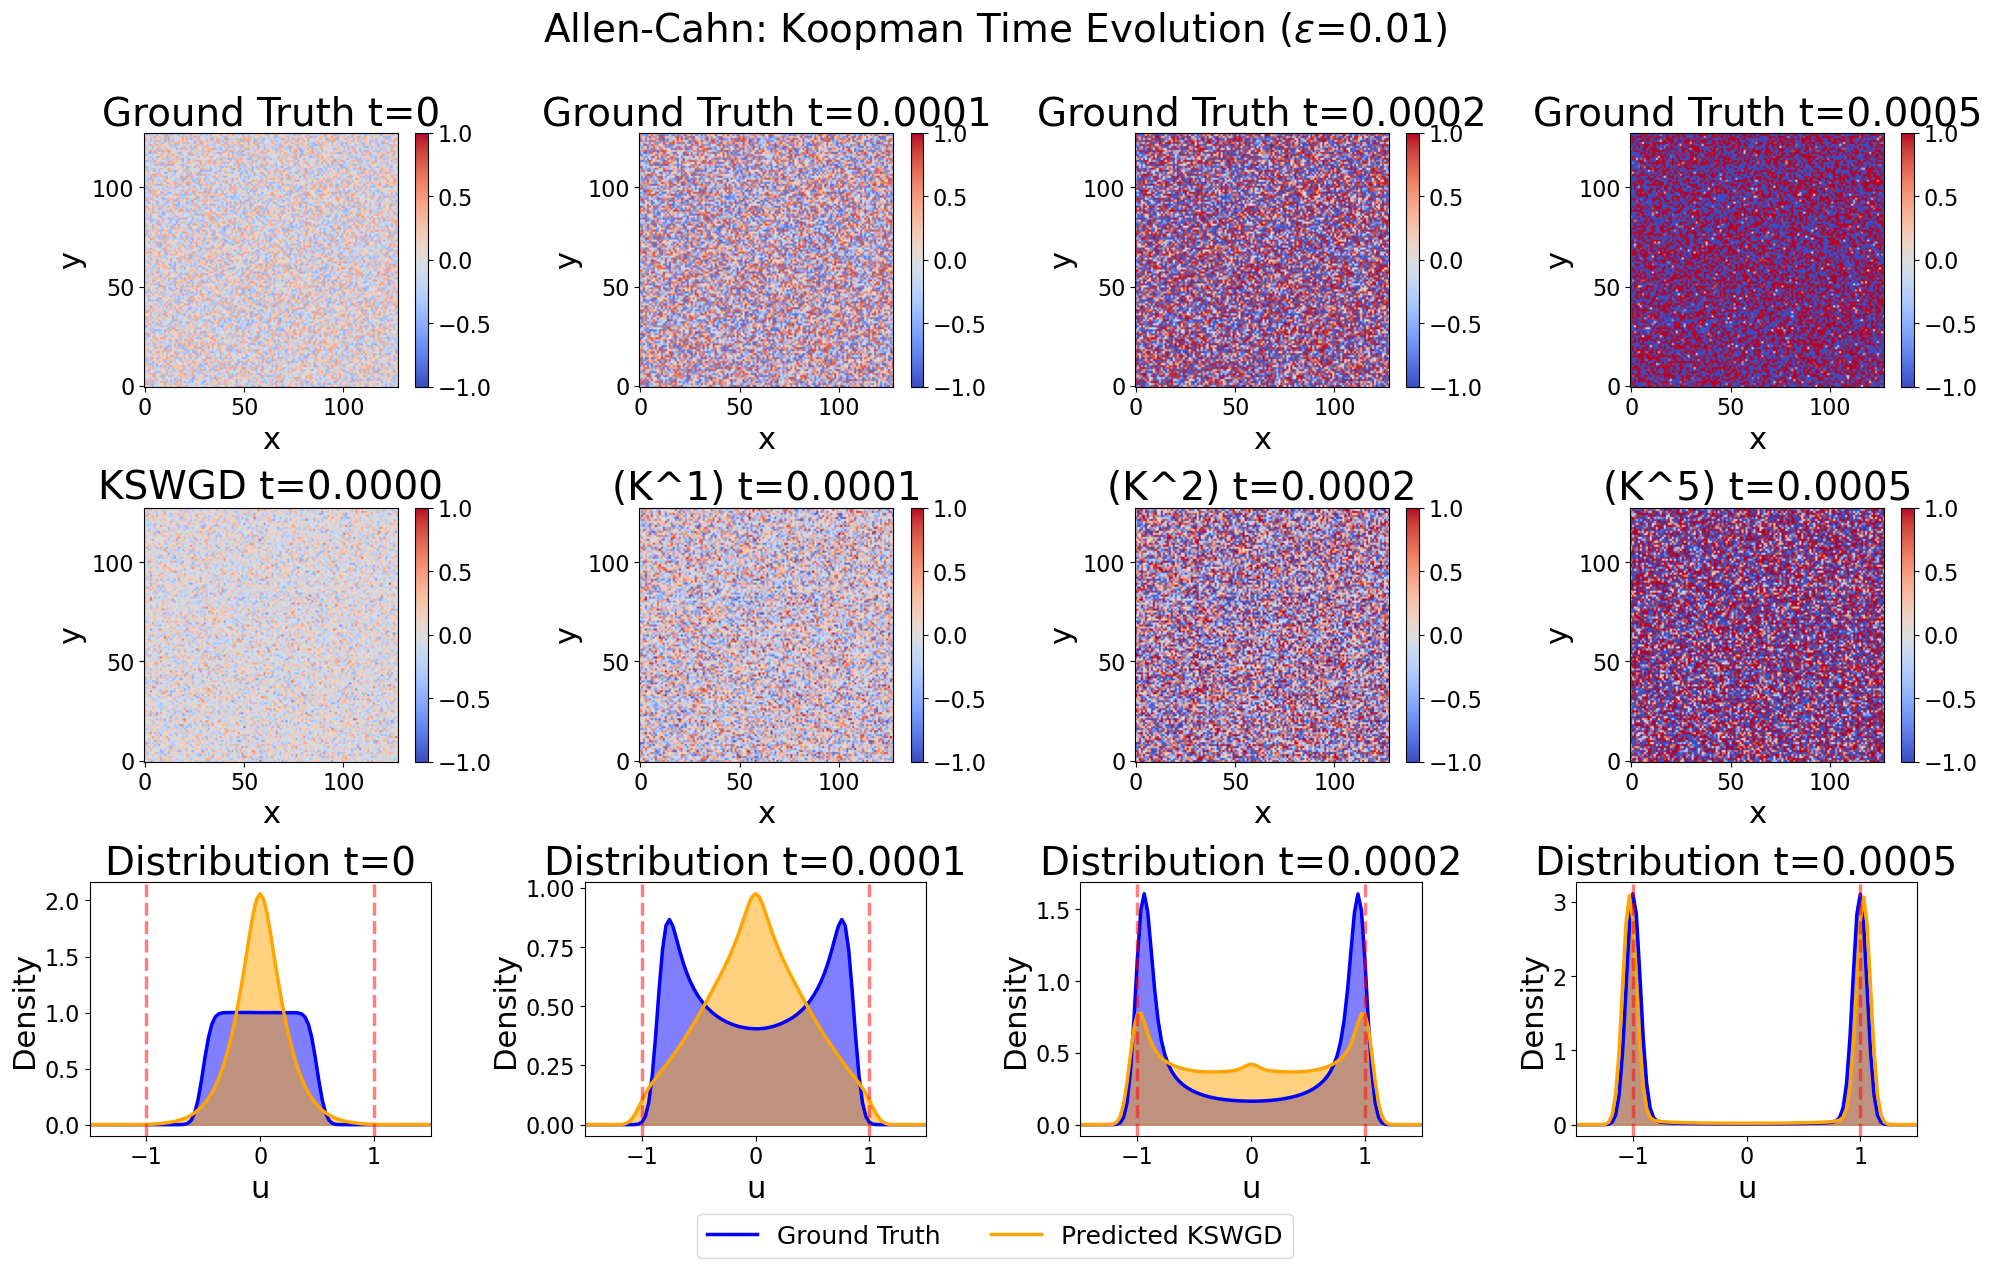


Distribution Statistics: Ground Truth vs Koopman Predictions

t = 0 (KSWGD):
  Ground Truth: mean=-0.0001, std=0.2887, near ±1: 0.0%
  Predicted:    mean=0.0002, std=0.2311, near ±1: 0.3%

t = 0.0001 (K^1):
  Ground Truth: mean=-0.0003, std=0.5664, near ±1: 12.3%
  Predicted:    mean=-0.0001, std=0.4472, near ±1: 8.2%

t = 0.0002 (K^2):
  Ground Truth: mean=-0.0005, std=0.8027, near ±1: 62.1%
  Predicted:    mean=-0.0008, std=0.6944, near ±1: 37.9%

t = 0.0005 (K^5):
  Ground Truth: mean=-0.0007, std=0.9840, near ±1: 97.5%
  Predicted:    mean=-0.0023, std=1.0158, near ±1: 95.9%


In [7]:
# === Visualization: Koopman Predictions vs Ground Truth ===
from scipy.ndimage import gaussian_filter1d

time_points = kswgd_time_results['meta']['time_points']
dt_koopman = kswgd_time_results['meta']['dt_koopman']
n_times = len(time_points)

fig, axes = plt.subplots(3, n_times, figsize=(5*n_times, 13))

# Store line handles for shared legend
legend_handles = []
legend_labels = []

for col, t_phys in enumerate(time_points):
    result = kswgd_time_results[t_phys]
    gt_samples = result['ground_truth_samples']
    pred_samples = result['predicted_samples']
    
    n_koopman = result.get('n_koopman_steps', 0)
    title_suffix = f"(K^{n_koopman})" if n_koopman > 0 else "KSWGD"
    
    # Row 1: Ground Truth Sample
    ax = axes[0, col]
    im = ax.imshow(gt_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    ax.set_title(f'Ground Truth t={t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('y', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)
    
    # Row 2: Koopman Predicted Sample
    ax = axes[1, col]
    im = ax.imshow(pred_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    t_pred = dt_koopman * n_koopman if n_koopman > 0 else 0
    ax.set_title(f'{title_suffix} t={t_pred:.4f}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('y', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)
    
    # Row 3: Distribution Comparison using KDE (smoothed)
    ax = axes[2, col]
    gt_values = gt_samples.flatten()
    pred_values = pred_samples.flatten()
    
    # Use histogram with smoothing (Gaussian kernel density estimation approximation)
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Compute histograms
    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    pred_hist, _ = np.histogram(pred_values, bins=bins, density=True)
    
    # Apply Gaussian smoothing to make the distribution smoother
    # This helps visualize the bimodal peaks better
    sigma = 2  # Smoothing parameter
    gt_hist_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    pred_hist_smooth = gaussian_filter1d(pred_hist, sigma=sigma)
    
    # Plot smoothed distributions (no individual legend)
    ax.fill_between(bin_centers, gt_hist_smooth, alpha=0.5, color='blue')
    l1, = ax.plot(bin_centers, gt_hist_smooth, color='blue', linewidth=PLOT_LINEWIDTH)
    ax.fill_between(bin_centers, pred_hist_smooth, alpha=0.5, color='orange')
    l2, = ax.plot(bin_centers, pred_hist_smooth, color='orange', linewidth=PLOT_LINEWIDTH)
    
    # Store handles from first column only
    if col == 0:
        legend_handles = [l1, l2]
        legend_labels = ['Ground Truth', f'Predicted {title_suffix}']
    
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_title(f'Distribution t={t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='red', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)

# Add shared horizontal legend at the bottom
fig.legend(legend_handles, legend_labels, 
           loc='lower center', 
           ncol=2,  # Horizontal layout
           fontsize=PLOT_LEGEND_FONTSIZE_GRID,
           frameon=True,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle(f'Allen-Cahn: Koopman Time Evolution ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # Leave space for legend at bottom
plt.show()

# === Distribution Distance Metrics ===
from scipy.stats import wasserstein_distance

def compute_wasserstein_2(p_samples, q_samples):
    """Compute Wasserstein-2 distance for 1D distributions."""
    p_sorted = np.sort(p_samples)
    q_sorted = np.sort(q_samples)
    n = min(len(p_sorted), len(q_sorted))
    p_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(p_sorted)), p_sorted)
    q_interp = np.interp(np.linspace(0, 1, n), np.linspace(0, 1, len(q_sorted)), q_sorted)
    w2 = np.sqrt(np.mean((p_interp - q_interp)**2))
    return w2

# Print statistics comparison
print("\n" + "="*70)
print("Distribution Statistics: Ground Truth vs Koopman Predictions")
print("="*70)

for t_phys in time_points:
    result = kswgd_time_results[t_phys]
    gt = result['ground_truth_samples'].flatten()
    pred = result['predicted_samples'].flatten()
    n_koopman = result.get('n_koopman_steps', 0)
    
    # Fraction near ±1 (bimodality measure)
    gt_near_pm1 = np.mean(np.abs(gt) > 0.8)
    pred_near_pm1 = np.mean(np.abs(pred) > 0.8)
    
    method = f"K^{n_koopman}" if n_koopman > 0 else "KSWGD"
    
    print(f"\nt = {t_phys} ({method}):")
    print(f"  Ground Truth: mean={np.mean(gt):.4f}, std={np.std(gt):.4f}, near ±1: {gt_near_pm1:.1%}")
    print(f"  Predicted:    mean={np.mean(pred):.4f}, std={np.std(pred):.4f}, near ±1: {pred_near_pm1:.1%}")

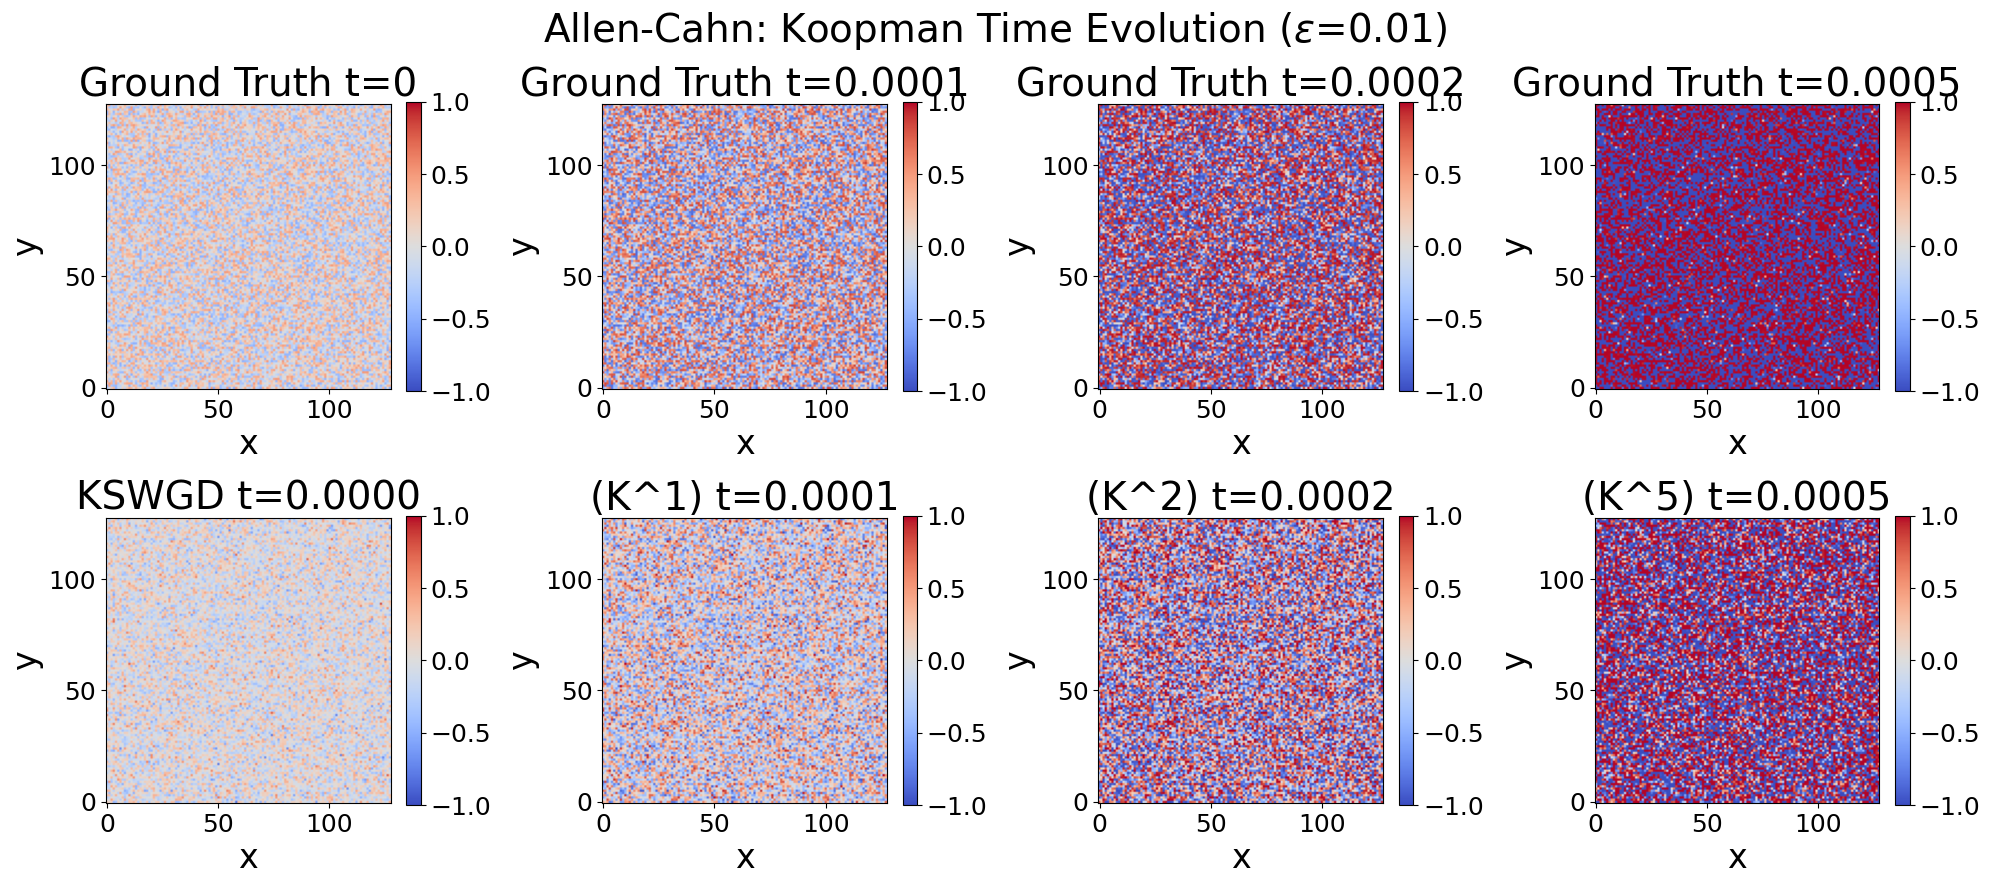

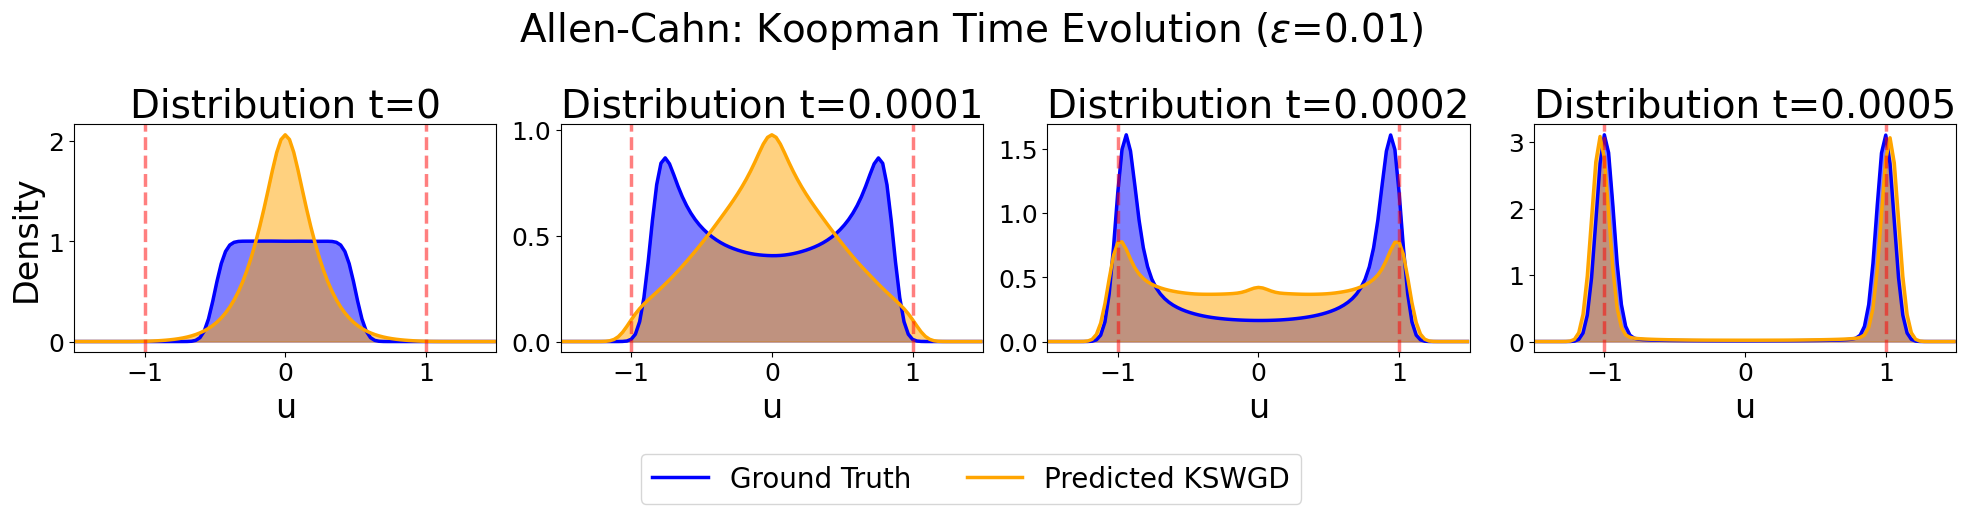

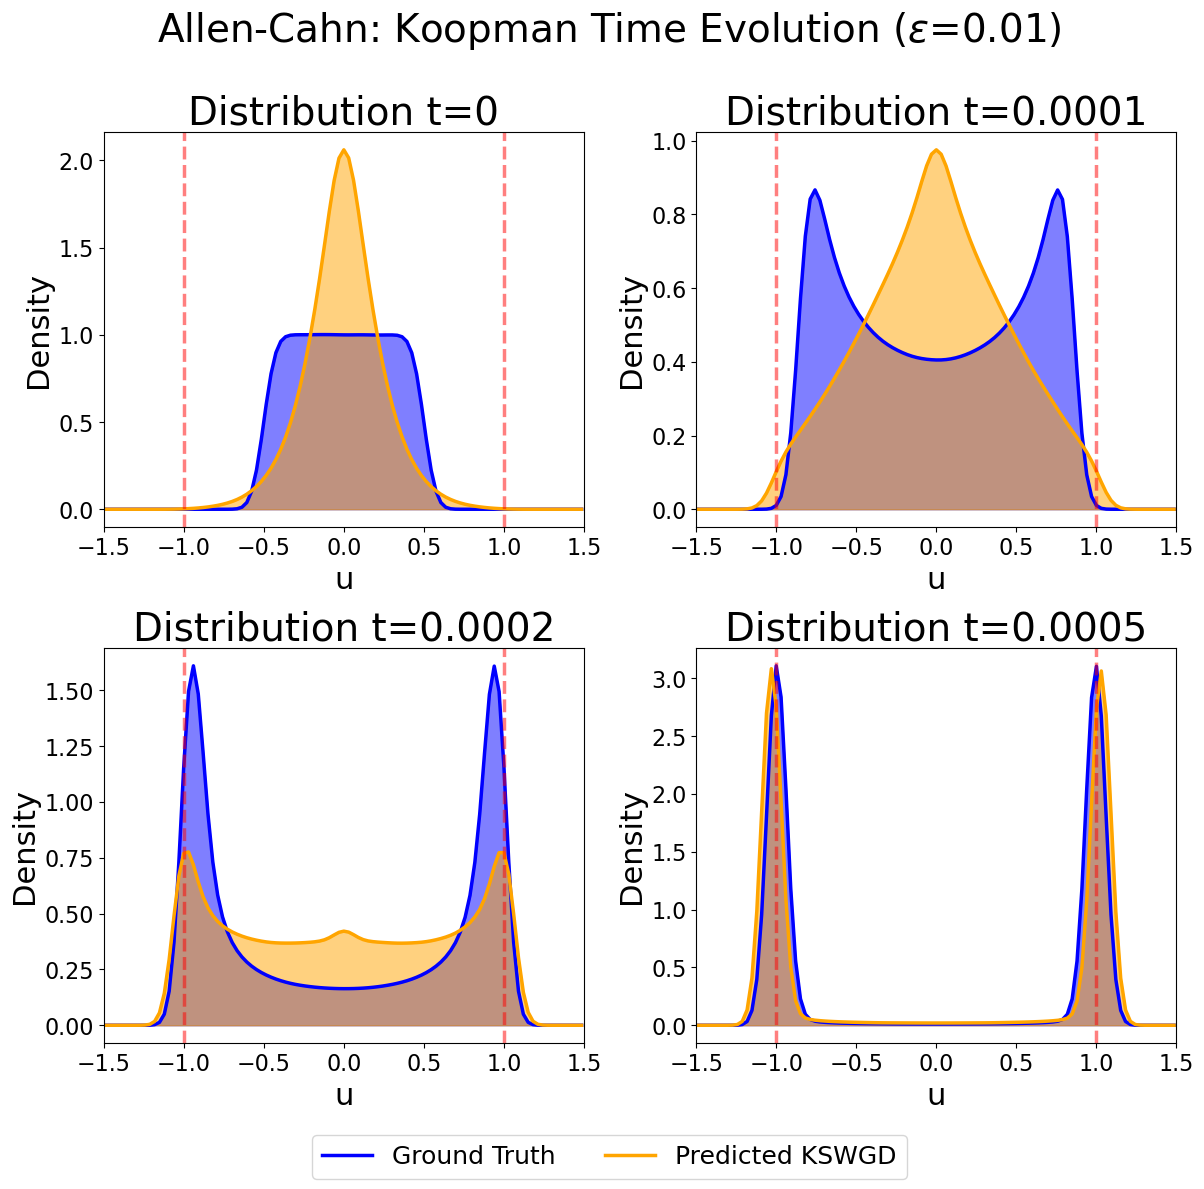

In [8]:
# === Modified Visualization: Split into Two Separate Figures ===

# Figure 1: Ground Truth and Koopman Predicted Samples (First Two Rows)
fig, axes = plt.subplots(2, n_times, figsize=(5*n_times, 9))

for col, t_phys in enumerate(time_points):
    result = kswgd_time_results[t_phys]
    gt_samples = result['ground_truth_samples']
    pred_samples = result['predicted_samples']
    
    n_koopman = result.get('n_koopman_steps', 0)
    title_suffix = f"(K^{n_koopman})" if n_koopman > 0 else "KSWGD"
    
    # Row 1: Ground Truth Sample
    ax = axes[0, col]
    im = ax.imshow(gt_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    ax.set_title(f'Ground Truth t={t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_ylabel('y', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)
    
    # Row 2: Koopman Predicted Sample
    ax = axes[1, col]
    im = ax.imshow(pred_samples[0], cmap='coolwarm', origin='lower', vmin=-1, vmax=1)
    t_pred = dt_koopman * n_koopman if n_koopman > 0 else 0
    ax.set_title(f'{title_suffix} t={t_pred:.4f}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel('x', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_ylabel('y', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046)
    cbar.ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)

plt.suptitle(f'Allen-Cahn: Koopman Time Evolution ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout()
plt.show()

# Figure 2: Distribution Comparison (Third Row) - 1x4 Layout
fig2, axes2 = plt.subplots(1, n_times, figsize=(5*n_times, 5))

# Store line handles for shared legend
legend_handles_1x4 = []
legend_labels_1x4 = []

for col, t_phys in enumerate(time_points):
    result = kswgd_time_results[t_phys]
    gt_samples = result['ground_truth_samples']
    pred_samples = result['predicted_samples']
    
    n_koopman = result.get('n_koopman_steps', 0)
    title_suffix = f"(K^{n_koopman})" if n_koopman > 0 else "KSWGD"
    
    # Distribution Comparison using KDE (smoothed)
    ax = axes2[col]
    gt_values = gt_samples.flatten()
    pred_values = pred_samples.flatten()
    
    # Use histogram with smoothing (Gaussian kernel density estimation approximation)
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Compute histograms
    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    pred_hist, _ = np.histogram(pred_values, bins=bins, density=True)
    
    # Apply Gaussian smoothing to make the distribution smoother
    sigma = 2  # Smoothing parameter
    gt_hist_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    pred_hist_smooth = gaussian_filter1d(pred_hist, sigma=sigma)
    
    # Plot smoothed distributions
    ax.fill_between(bin_centers, gt_hist_smooth, alpha=0.5, color='blue')
    l1, = ax.plot(bin_centers, gt_hist_smooth, color='blue', linewidth=PLOT_LINEWIDTH)
    ax.fill_between(bin_centers, pred_hist_smooth, alpha=0.5, color='orange')
    l2, = ax.plot(bin_centers, pred_hist_smooth, color='orange', linewidth=PLOT_LINEWIDTH)
    
    # Store handles from first column only
    if col == 0:
        legend_handles_1x4 = [l1, l2]
        legend_labels_1x4 = ['Ground Truth', f'Predicted {title_suffix}']
    
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    if col == 0:
        ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_title(f'Distribution t={t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='red', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)

# Add shared horizontal legend at the bottom
fig2.legend(legend_handles_1x4, legend_labels_1x4, 
           loc='lower center', 
           ncol=2,  # Horizontal layout
           fontsize=PLOT_LEGEND_FONTSIZE_WIDE,
           frameon=True,
           bbox_to_anchor=(0.5, -0.0375))

plt.suptitle(f'Allen-Cahn: Koopman Time Evolution ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout(rect=[0, 0.12, 1, 0.97])  # Leave balanced space for legend at bottom
plt.show()

# Figure 3: Distribution Comparison (Third Row) - 2x2 Layout
n_cols = 2
n_rows = (n_times + n_cols - 1) // n_cols  # Calculate rows needed for 2x2 layout

fig3, axes3 = plt.subplots(n_rows, n_cols, figsize=(12, 6*n_rows))
axes3 = axes3.flatten()  # Flatten for easy indexing

# Store line handles for shared legend
legend_handles_2x2 = []
legend_labels_2x2 = []

for idx, t_phys in enumerate(time_points):
    result = kswgd_time_results[t_phys]
    gt_samples = result['ground_truth_samples']
    pred_samples = result['predicted_samples']
    
    n_koopman = result.get('n_koopman_steps', 0)
    title_suffix = f"(K^{n_koopman})" if n_koopman > 0 else "KSWGD"
    
    # Distribution Comparison using KDE (smoothed)
    ax = axes3[idx]
    gt_values = gt_samples.flatten()
    pred_values = pred_samples.flatten()
    
    # Use histogram with smoothing (Gaussian kernel density estimation approximation)
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Compute histograms
    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    pred_hist, _ = np.histogram(pred_values, bins=bins, density=True)
    
    # Apply Gaussian smoothing to make the distribution smoother
    sigma = 2  # Smoothing parameter
    gt_hist_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    pred_hist_smooth = gaussian_filter1d(pred_hist, sigma=sigma)
    
    # Plot smoothed distributions (no individual legend)
    ax.fill_between(bin_centers, gt_hist_smooth, alpha=0.5, color='blue')
    l1, = ax.plot(bin_centers, gt_hist_smooth, color='blue', linewidth=PLOT_LINEWIDTH)
    ax.fill_between(bin_centers, pred_hist_smooth, alpha=0.5, color='orange')
    l2, = ax.plot(bin_centers, pred_hist_smooth, color='orange', linewidth=PLOT_LINEWIDTH)
    
    # Store handles from first subplot only
    if idx == 0:
        legend_handles_2x2 = [l1, l2]
        legend_labels_2x2 = ['Ground Truth', f'Predicted {title_suffix}']
    
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_title(f'Distribution t={t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='red', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(x=1, color='red', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)

# Hide any unused subplots
for idx in range(n_times, len(axes3)):
    axes3[idx].axis('off')

# Add shared horizontal legend at the bottom
fig3.legend(legend_handles_2x2, legend_labels_2x2, 
           loc='lower center', 
           ncol=2,  # Horizontal layout
           fontsize=PLOT_LEGEND_FONTSIZE_GRID,
           frameon=True,
           bbox_to_anchor=(0.5, -0.005))

plt.suptitle(f'Allen-Cahn: Koopman Time Evolution ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # Leave less extra space for legend at bottom
plt.show()

## Baseline Comparison: Diffusion, VAE, Normalizing Flow & GAN
We benchmark KSWGD against four latent-space generators:
1. **Diffusion Model (DDPM)** – noise-conditioned denoiser.
2. **Variational Autoencoder (VAE)** – latent-variable model with KL control.
3. **Normalizing Flow (RealNVP)** – invertible density model with exact likelihoods.
4. **GAN (WGAN-GP)** – adversarial sampler learning a deterministic map.

All baselines:
- Train separately for each time slice using the shared AE latent space.
- Draw the same number of samples for evaluation.
- Share decoding + metrics so comparisons remain apples-to-apples.

In [9]:
# === Diffusion / VAE / Normalizing Flow / GAN baselines (latent space) ===
print("="*70)
print("Training Latent-Space Baselines for Allen-Cahn")
print("="*70)

class DiffusionModel(nn.Module):
    """MLP-based diffusion model for latent space."""
    def __init__(self, latent_dim, hidden_dim=256, time_emb_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(1, time_emb_dim),
            nn.SiLU(),
            nn.Linear(time_emb_dim, time_emb_dim)
        )
        self.net = nn.Sequential(
            nn.Linear(latent_dim + time_emb_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim)
        )
    
    def forward(self, x, t):
        t_emb = self.time_mlp(t.unsqueeze(-1))
        return self.net(torch.cat([x, t_emb], dim=-1))

class VAELatent(nn.Module):
    """VAE operating in latent space (latent -> smaller latent -> latent)."""
    def __init__(self, latent_dim, hidden_dim=128, vae_latent_dim=4):
        super().__init__()
        self.vae_latent_dim = vae_latent_dim
        self.encoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
)
        self.fc_mu = nn.Linear(hidden_dim, vae_latent_dim)
        self.fc_var = nn.Linear(hidden_dim, vae_latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(vae_latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim)
)
    
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_var(h)
    
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        return self.decoder(z)
    
    def forward(self, x):
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        return self.decode(z), mu, log_var

class AffineCoupling(nn.Module):
    """Single RealNVP affine coupling layer."""
    def __init__(self, dim, hidden_dim, mask):
        super().__init__()
        self.register_buffer('mask', mask)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 2 * dim)
        )
    
    def forward(self, x, reverse=False):
        masked_x = x * self.mask
        s_t = self.net(masked_x)
        s, t = torch.chunk(s_t, 2, dim=1)
        s = torch.tanh(s)
        one_minus = 1 - self.mask
        if not reverse:
            y = masked_x + one_minus * (x * torch.exp(s) + t)
            log_det = torch.sum(one_minus * s, dim=1)
        else:
            y = masked_x + one_minus * ((x - t) * torch.exp(-s))
            log_det = -torch.sum(one_minus * s, dim=1)
        return y, log_det

class RealNVPFlow(nn.Module):
    """Stack of coupling layers implementing a normalizing flow."""
    def __init__(self, dim, hidden_dim=128, n_layers=4):
        super().__init__()
        masks = []
        for i in range(n_layers):
            mask_pattern = (torch.arange(dim) % 2 == (i % 2)).float()
            masks.append(mask_pattern)
        self.layers = nn.ModuleList([AffineCoupling(dim, hidden_dim, mask) for mask in masks])
        self.dim = dim
    
    def _forward_layers(self, x, reverse=False):
        log_det_sum = 0.0
        layers = list(reversed(self.layers)) if reverse else self.layers
        for layer in layers:
            x, log_det = layer(x, reverse=reverse)
            log_det_sum = log_det_sum + log_det
        return x, log_det_sum
    
    def log_prob(self, x):
        z, log_det = self._forward_layers(x, reverse=False)
        log_base = -0.5 * (z**2 + torch.log(torch.tensor(2 * np.pi, device=z.device))).sum(dim=1)
        return log_base + log_det
    
    def sample(self, n_samples):
        z = torch.randn(n_samples, self.dim, device=device)
        x, _ = self._forward_layers(z, reverse=True)
        return x

class LatentGenerator(nn.Module):
    """Simple generator for latent GAN."""
    def __init__(self, latent_dim, noise_dim=16, hidden_dim=256):
        super().__init__()
        self.noise_dim = noise_dim
        self.net = nn.Sequential(
            nn.Linear(noise_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, latent_dim)
)
    
    def forward(self, z):
        return self.net(z)

class LatentCritic(nn.Module):
    """WGAN-GP critic over latent vectors."""
    def __init__(self, latent_dim, hidden_dim=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 1)
)
    
    def forward(self, x):
        return self.net(x).squeeze(-1)

def gradient_penalty(critic, real, fake):
    batch_size = real.size(0)
    epsilon = torch.rand(batch_size, 1, device=real.device)
    interp = epsilon * real + (1 - epsilon) * fake
    interp.requires_grad_(True)
    scores = critic(interp)
    gradients = torch.autograd.grad(
        outputs=scores, inputs=interp,
        grad_outputs=torch.ones_like(scores),
        create_graph=True, retain_graph=True, only_inputs=True
    )[0]
    gradients = gradients.view(batch_size, -1)
    return ((gradients.norm(2, dim=1) - 1) ** 2).mean()

def train_latent_baselines_for_time(time_series_ensemble, target_time, ae, data_min, data_max,
                                      latent_dim=8, n_epochs=150, n_samples_gen=100, verbose=True):
    """Train Diffusion, VAE, RealNVP, and GAN for a specific time point."""
    data_range = data_max - data_min + 1e-8
    data = time_series_ensemble[target_time]
    n_samples, N, _ = data.shape
    
    # Encode to latent space
    ae.eval()
    data_flat = data.reshape(-1, N*N)
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    with torch.no_grad():
        tensor = torch.FloatTensor(data_scaled).to(device).view(-1, N, N)
        Z_data = ae.encoder(tensor).cpu().numpy()
    
    z_mean = Z_data.mean(axis=0)
    z_std = Z_data.std(axis=0) + 1e-8
    Z_norm = (Z_data - z_mean) / z_std
    
    train_tensor = torch.FloatTensor(Z_norm).to(device)
    train_loader = DataLoader(TensorDataset(train_tensor), batch_size=32, shuffle=True)
    
    # Diffusion model
    if verbose:
        print(f"\n  Training Diffusion Model for t={target_time}...")
    n_timesteps = 200
    betas = torch.linspace(1e-4, 0.02, n_timesteps).to(device)
    alphas = 1 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    diffusion = DiffusionModel(latent_dim, hidden_dim=256).to(device)
    optimizer_diff = optim.Adam(diffusion.parameters(), lr=1e-3)

    def q_sample(x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod[t]).unsqueeze(-1)
        sqrt_one_minus = torch.sqrt(1 - alphas_cumprod[t]).unsqueeze(-1)
        return sqrt_alpha_cumprod * x0 + sqrt_one_minus * noise, noise

    for epoch in range(n_epochs):
        total_loss = 0.0
        for (batch,) in train_loader:
            optimizer_diff.zero_grad()
            t = torch.randint(0, n_timesteps, (batch.shape[0],), device=device)
            x_noisy, noise = q_sample(batch, t)
            noise_pred = diffusion(x_noisy, t.float() / n_timesteps)
            loss = nn.MSELoss()(noise_pred, noise)
            loss.backward()
            optimizer_diff.step()
            total_loss += loss.item()
        if verbose and (epoch + 1) % 50 == 0:
            print(f"    Diffusion Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_loader):.6f}")

    @torch.no_grad()
    def sample_diffusion(model, n_samples):
        x = torch.randn(n_samples, latent_dim, device=device)
        for t in reversed(range(n_timesteps)):
            t_batch = torch.full((n_samples,), t, device=device)
            noise_pred = model(x, t_batch.float() / n_timesteps)
            alpha = alphas[t]
            alpha_cumprod_t = alphas_cumprod[t]
            beta = betas[t]
            noise = torch.randn_like(x) if t > 0 else 0
            x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_cumprod_t)) * noise_pred)
            x = x + torch.sqrt(beta) * noise
        return x

    diff_latent_norm = sample_diffusion(diffusion, n_samples_gen).cpu().numpy()
    diff_latent = diff_latent_norm * z_std + z_mean

    # VAE
    if verbose:
        print(f"\n  Training VAE for t={target_time}...")
    vae = VAELatent(latent_dim, hidden_dim=128, vae_latent_dim=4).to(device)
    optimizer_vae = optim.Adam(vae.parameters(), lr=1e-3)

    def vae_loss(recon_x, x, mu, log_var, beta=0.1):
        recon_loss = nn.MSELoss(reduction='sum')(recon_x, x)
        kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        return recon_loss + beta * kl_loss

    for epoch in range(n_epochs):
        total_loss = 0.0
        for (batch,) in train_loader:
            optimizer_vae.zero_grad()
            recon, mu, log_var = vae(batch)
            loss = vae_loss(recon, batch, mu, log_var, beta=0.1)
            loss.backward()
            optimizer_vae.step()
            total_loss += loss.item()
        if verbose and (epoch + 1) % 50 == 0:
            print(f"    VAE Epoch {epoch+1}/{n_epochs}, Loss: {total_loss/len(train_tensor):.4f}")

    @torch.no_grad()
    def sample_vae(model, n_samples):
        z = torch.randn(n_samples, model.vae_latent_dim, device=device)
        return model.decode(z)

    vae_latent_norm = sample_vae(vae, n_samples_gen).cpu().numpy()
    vae_latent = vae_latent_norm * z_std + z_mean

    # Normalizing Flow
    if verbose:
        print(f"\n  Training RealNVP Flow for t={target_time}...")
    flow = RealNVPFlow(latent_dim, hidden_dim=128, n_layers=4).to(device)
    optimizer_flow = optim.Adam(flow.parameters(), lr=1e-3)
    for epoch in range(n_epochs):
        total_loss = 0.0
        for (batch,) in train_loader:
            optimizer_flow.zero_grad()
            loss = -flow.log_prob(batch).mean()
            loss.backward()
            optimizer_flow.step()
            total_loss += loss.item()
        if verbose and (epoch + 1) % 50 == 0:
            print(f"    Flow Epoch {epoch+1}/{n_epochs}, NLL: {total_loss/len(train_loader):.6f}")

    flow_latent_norm = flow.sample(n_samples_gen).detach().cpu().numpy()
    flow_latent = flow_latent_norm * z_std + z_mean

    # GAN (WGAN-GP)
    if verbose:
        print(f"\n  Training WGAN-GP for t={target_time}...")
    noise_dim = 16
    generator = LatentGenerator(latent_dim, noise_dim=noise_dim, hidden_dim=256).to(device)
    critic = LatentCritic(latent_dim, hidden_dim=256).to(device)
    optimizer_gen = optim.Adam(generator.parameters(), lr=1e-4, betas=(0.5, 0.9))
    optimizer_critic = optim.Adam(critic.parameters(), lr=1e-4, betas=(0.5, 0.9))
    n_critic = 5
    lambda_gp = 10.0

    for epoch in range(n_epochs):
        for (batch,) in train_loader:
            real = batch
            for _ in range(n_critic):
                noise = torch.randn(real.size(0), noise_dim, device=device)
                fake = generator(noise)
                critic_real = critic(real).mean()
                critic_fake = critic(fake.detach()).mean()
                gp = gradient_penalty(critic, real, fake.detach())
                loss_critic = critic_fake - critic_real + lambda_gp * gp
                optimizer_critic.zero_grad()
                loss_critic.backward()
                optimizer_critic.step()
            noise = torch.randn(real.size(0), noise_dim, device=device)
            fake = generator(noise)
            loss_gen = -critic(fake).mean()
            optimizer_gen.zero_grad()
            loss_gen.backward()
            optimizer_gen.step()
        if verbose and (epoch + 1) % 50 == 0:
            print(f"    GAN Epoch {epoch+1}/{n_epochs}, D_loss: {loss_critic.item():.4f}, G_loss: {loss_gen.item():.4f}")

    with torch.no_grad():
        gan_latent_norm = generator(torch.randn(n_samples_gen, noise_dim, device=device)).cpu().numpy()
    gan_latent = gan_latent_norm * z_std + z_mean

    # Decode to original space
    def decode_latent(z_latent):
        with torch.no_grad():
            z_tensor = torch.FloatTensor(z_latent).to(device)
            decoded = ae.decoder(z_tensor).cpu().numpy()
        samples = (decoded.reshape(-1, N*N) + 1.0) / 2.0 * data_range + data_min
        return samples.reshape(-1, N, N)

    return {
        'ground_truth': data,
        'diffusion_samples': decode_latent(diff_latent),
        'diffusion_latent': diff_latent,
        'vae_samples': decode_latent(vae_latent),
        'vae_latent': vae_latent,
        'flow_samples': decode_latent(flow_latent),
        'flow_latent': flow_latent,
        'gan_samples': decode_latent(gan_latent),
        'gan_latent': gan_latent,
    }

print("\nTraining baseline models for each time point...")
ae = kswgd_time_results['meta']['ae']
# Get latent_dim from the autoencoder to ensure consistency
latent_dim_ae = ae.latent_dim
all_data = np.concatenate([time_series_ensemble[t] for t in time_points], axis=0)
data_min = all_data.min()
data_max = all_data.max()

baseline_results = {}
for t_target in time_points:
    print(f"\n{'='*60}")
    print(f"Time t = {t_target}")
    print(f"{'='*60}")
    result = train_latent_baselines_for_time(
        time_series_ensemble,
        target_time=t_target,
        ae=ae,
        data_min=data_min,
        data_max=data_max,
        latent_dim=latent_dim_ae,  # Use actual AE latent dim (16)
        n_epochs=150,
        n_samples_gen=100,
        verbose=True
    )
    baseline_results[t_target] = result

print("\n" + "="*70)
print("Baseline model training complete!")
print("="*70)

Training Latent-Space Baselines for Allen-Cahn

Training baseline models for each time point...

Time t = 0

  Training Diffusion Model for t=0...
    Diffusion Epoch 50/150, Loss: 0.507844
    Diffusion Epoch 100/150, Loss: 0.490479
    Diffusion Epoch 150/150, Loss: 0.520198

  Training VAE for t=0...
    VAE Epoch 50/150, Loss: 6.5142
    VAE Epoch 100/150, Loss: 5.5792
    VAE Epoch 150/150, Loss: 4.9627

  Training RealNVP Flow for t=0...
    Flow Epoch 50/150, NLL: 13.536636
    Flow Epoch 100/150, NLL: 9.748363
    Flow Epoch 150/150, NLL: 7.497234

  Training WGAN-GP for t=0...
    GAN Epoch 50/150, D_loss: -2.0838, G_loss: -4.1915
    GAN Epoch 100/150, D_loss: -0.1910, G_loss: -5.9717
    GAN Epoch 150/150, D_loss: -0.4698, G_loss: -7.1810

Time t = 0.0001

  Training Diffusion Model for t=0.0001...
    Diffusion Epoch 50/150, Loss: 0.521461
    Diffusion Epoch 100/150, Loss: 0.511137
    Diffusion Epoch 150/150, Loss: 0.482813

  Training VAE for t=0.0001...
    VAE Epoch 50

FINAL COMPARISON: Distribution of All Generative Baselines


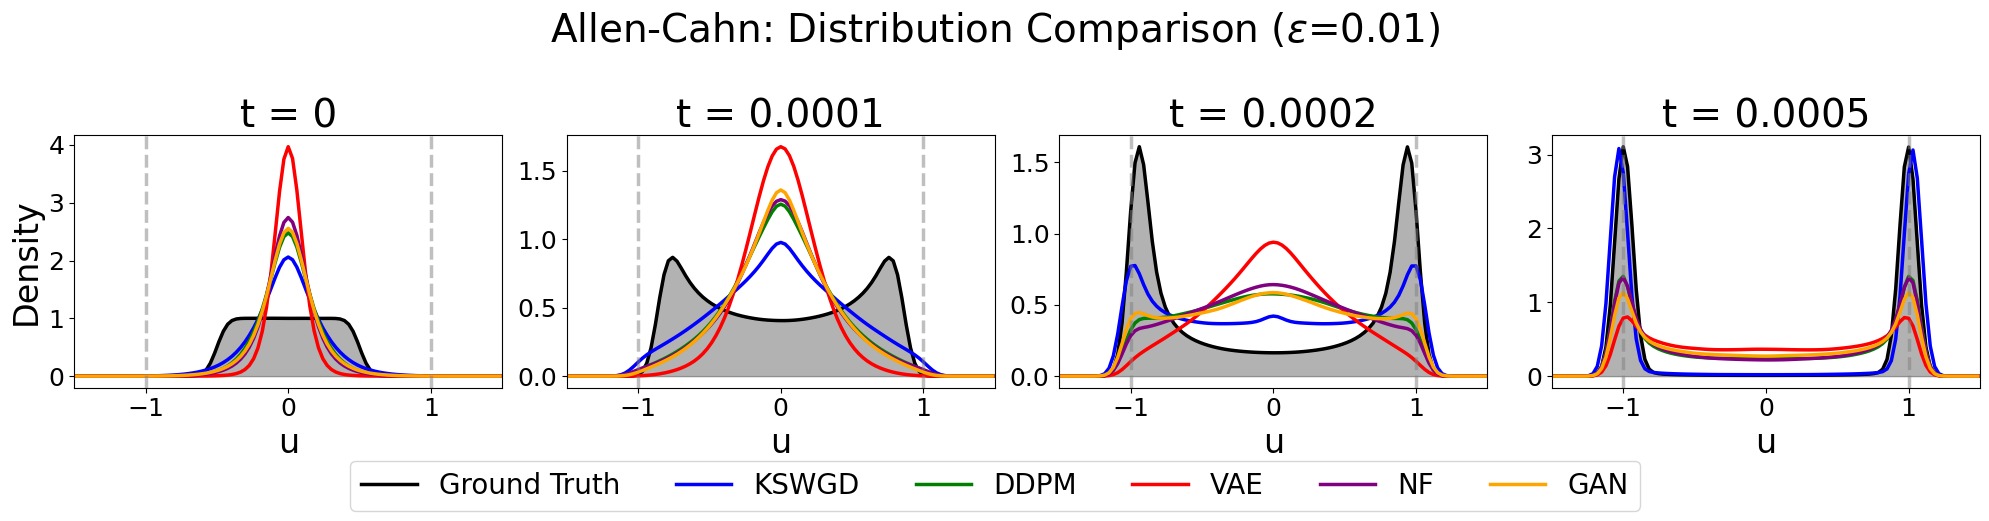

In [10]:
# === Distribution Comparison Figure (All Models) ===
from scipy.ndimage import gaussian_filter1d
from scipy.stats import wasserstein_distance

print("="*70)
print("FINAL COMPARISON: Distribution of All Generative Baselines")
print("="*70)

n_times = len(time_points)

# Create figure (no extra space on right needed now)
fig, axes2 = plt.subplots(1, n_times, figsize=(5*n_times, 5))

# Define colors and labels for legend
method_colors = {
    'Ground Truth': 'black',
    'KSWGD': 'blue',
    'Diffusion': 'green',
    'VAE': 'red',
    'NF': 'purple',
    'GAN': 'orange'
}

for col, t_phys in enumerate(time_points):
    kswgd_result = kswgd_time_results[t_phys]
    baseline_result = baseline_results[t_phys]

    gt_values = kswgd_result['ground_truth_samples'].flatten()
    kswgd_values = kswgd_result['predicted_samples'].flatten()
    diff_values = baseline_result['diffusion_samples'].flatten()
    vae_values = baseline_result['vae_samples'].flatten()
    flow_values = baseline_result['flow_samples'].flatten()
    gan_values = baseline_result['gan_samples'].flatten()

    ax = axes2[col]
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    sigma = 2

    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    kswgd_hist, _ = np.histogram(kswgd_values, bins=bins, density=True)
    diff_hist, _ = np.histogram(diff_values, bins=bins, density=True)
    vae_hist, _ = np.histogram(vae_values, bins=bins, density=True)
    flow_hist, _ = np.histogram(flow_values, bins=bins, density=True)
    gan_hist, _ = np.histogram(gan_values, bins=bins, density=True)

    gt_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    kswgd_smooth = gaussian_filter1d(kswgd_hist, sigma=sigma)
    diff_smooth = gaussian_filter1d(diff_hist, sigma=sigma)
    vae_smooth = gaussian_filter1d(vae_hist, sigma=sigma)
    flow_smooth = gaussian_filter1d(flow_hist, sigma=sigma)
    gan_smooth = gaussian_filter1d(gan_hist, sigma=sigma)

    # Plot without individual legends
    ax.fill_between(bin_centers, gt_smooth, alpha=0.3, color='black')
    l1, = ax.plot(bin_centers, gt_smooth, color='black', linewidth=PLOT_LINEWIDTH)
    l2, = ax.plot(bin_centers, kswgd_smooth, color='blue', linewidth=PLOT_LINEWIDTH)
    l3, = ax.plot(bin_centers, diff_smooth, color='green', linewidth=PLOT_LINEWIDTH)
    l4, = ax.plot(bin_centers, vae_smooth, color='red', linewidth=PLOT_LINEWIDTH)
    l5, = ax.plot(bin_centers, flow_smooth, color='purple', linewidth=PLOT_LINEWIDTH)
    l6, = ax.plot(bin_centers, gan_smooth, color='orange', linewidth=PLOT_LINEWIDTH)
    
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    if col == 0:
        ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_WIDE)
    ax.set_title(f't = {t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='gray', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_WIDE)

# Create shared horizontal legend at the bottom
fig.legend([l1, l2, l3, l4, l5, l6], 
           ['Ground Truth', 'KSWGD', 'DDPM', 'VAE', 'NF', 'GAN'],
           loc='lower center', 
           ncol=6,  # All items in one row
           fontsize=PLOT_LEGEND_FONTSIZE_WIDE,
           frameon=True,
           bbox_to_anchor=(0.5, -0.05))

plt.suptitle(f'Allen-Cahn: Distribution Comparison ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout(rect=[0, 0.05, 1, 0.95])  # Leave extra space for legend at bottom
plt.show()

FINAL COMPARISON: Distribution of All Generative Baselines (2x2 Layout)


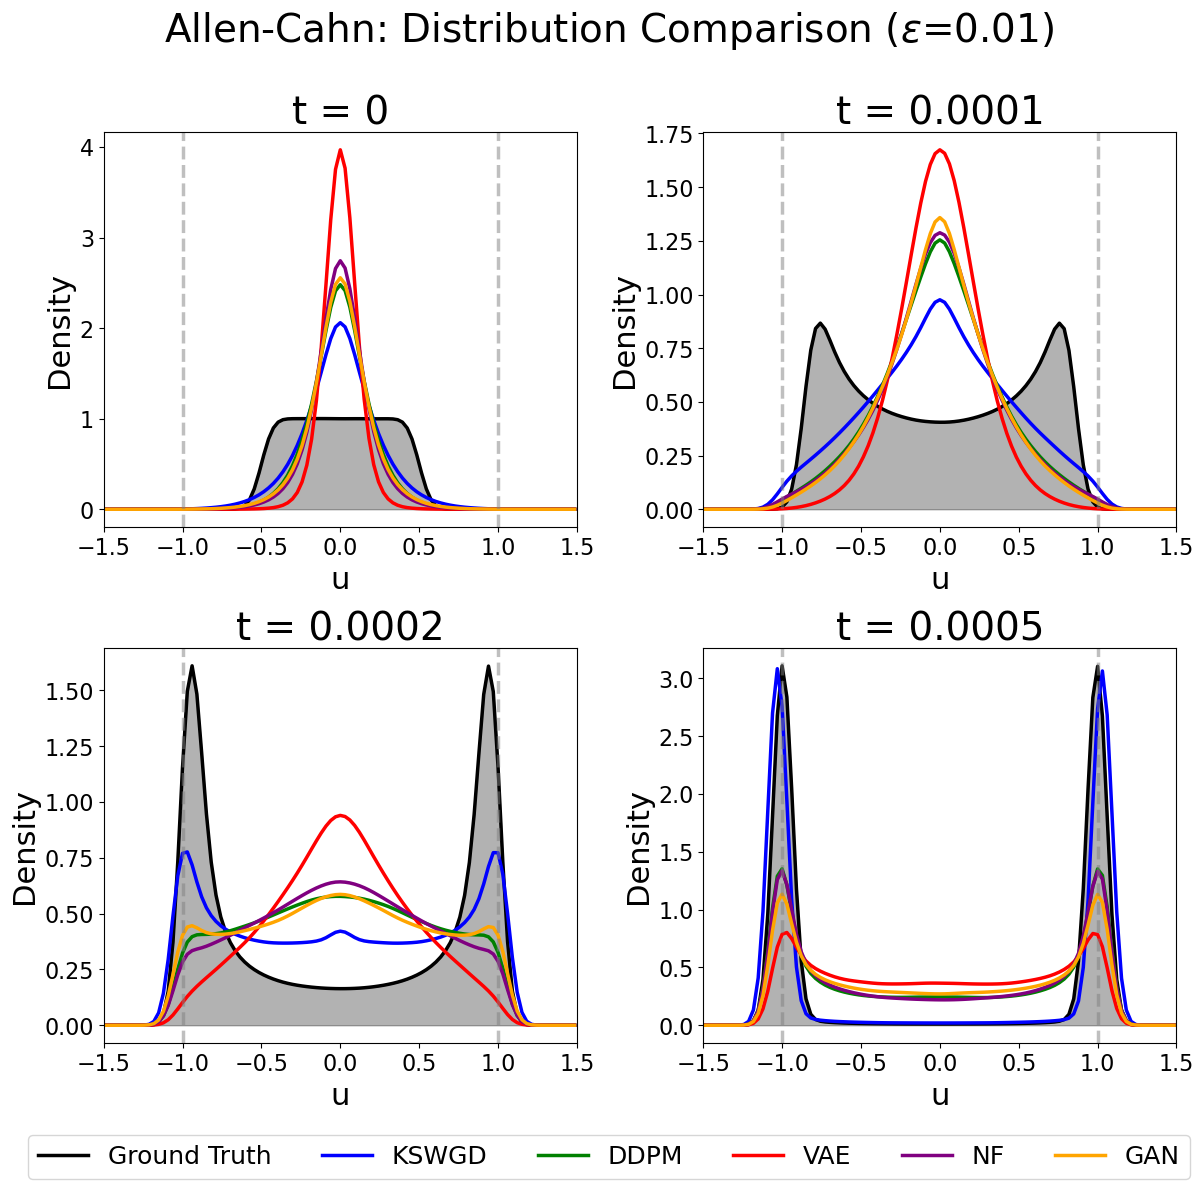

In [11]:
# === Distribution Comparison Figure (All Models) - 2x2 Layout ===
from scipy.ndimage import gaussian_filter1d

print("="*70)
print("FINAL COMPARISON: Distribution of All Generative Baselines (2x2 Layout)")
print("="*70)

n_times = len(time_points)
n_cols = 2
n_rows = (n_times + n_cols - 1) // n_cols  # Calculate rows needed for 2x2 layout

# Create figure with 2x2 layout (matching cell10's second figure specs)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6*n_rows))
axes = axes.flatten()  # Flatten for easy indexing

# Define colors and labels for legend
method_colors = {
    'Ground Truth': 'black',
    'KSWGD': 'blue',
    'Diffusion': 'green',
    'VAE': 'red',
    'NF': 'purple',
    'GAN': 'orange'
}

for idx, t_phys in enumerate(time_points):
    kswgd_result = kswgd_time_results[t_phys]
    baseline_result = baseline_results[t_phys]

    gt_values = kswgd_result['ground_truth_samples'].flatten()
    kswgd_values = kswgd_result['predicted_samples'].flatten()
    diff_values = baseline_result['diffusion_samples'].flatten()
    vae_values = baseline_result['vae_samples'].flatten()
    flow_values = baseline_result['flow_samples'].flatten()
    gan_values = baseline_result['gan_samples'].flatten()

    ax = axes[idx]
    bins = np.linspace(-1.5, 1.5, 100)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    sigma = 2

    gt_hist, _ = np.histogram(gt_values, bins=bins, density=True)
    kswgd_hist, _ = np.histogram(kswgd_values, bins=bins, density=True)
    diff_hist, _ = np.histogram(diff_values, bins=bins, density=True)
    vae_hist, _ = np.histogram(vae_values, bins=bins, density=True)
    flow_hist, _ = np.histogram(flow_values, bins=bins, density=True)
    gan_hist, _ = np.histogram(gan_values, bins=bins, density=True)

    gt_smooth = gaussian_filter1d(gt_hist, sigma=sigma)
    kswgd_smooth = gaussian_filter1d(kswgd_hist, sigma=sigma)
    diff_smooth = gaussian_filter1d(diff_hist, sigma=sigma)
    vae_smooth = gaussian_filter1d(vae_hist, sigma=sigma)
    flow_smooth = gaussian_filter1d(flow_hist, sigma=sigma)
    gan_smooth = gaussian_filter1d(gan_hist, sigma=sigma)

    # Plot distributions
    ax.fill_between(bin_centers, gt_smooth, alpha=0.3, color='black')
    l1, = ax.plot(bin_centers, gt_smooth, color='black', linewidth=PLOT_LINEWIDTH)
    l2, = ax.plot(bin_centers, kswgd_smooth, color='blue', linewidth=PLOT_LINEWIDTH)
    l3, = ax.plot(bin_centers, diff_smooth, color='green', linewidth=PLOT_LINEWIDTH)
    l4, = ax.plot(bin_centers, vae_smooth, color='red', linewidth=PLOT_LINEWIDTH)
    l5, = ax.plot(bin_centers, flow_smooth, color='purple', linewidth=PLOT_LINEWIDTH)
    l6, = ax.plot(bin_centers, gan_smooth, color='orange', linewidth=PLOT_LINEWIDTH)
    
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_title(f't = {t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(x=-1, color='gray', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(x=1, color='gray', linestyle='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)

# Hide any unused subplots
for idx in range(n_times, len(axes)):
    axes[idx].axis('off')

# Create shared horizontal legend at the bottom
fig.legend([l1, l2, l3, l4, l5, l6], 
           ['Ground Truth', 'KSWGD', 'DDPM', 'VAE', 'NF', 'GAN'],
           loc='lower center', 
           ncol=6,  # All items in one row
           fontsize=PLOT_LEGEND_FONTSIZE_GRID,
           frameon=True,
           bbox_to_anchor=(0.5, -0.005))

plt.suptitle(f'Allen-Cahn: Distribution Comparison ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
plt.tight_layout(rect=[0, 0.05, 1, 0.97])  # Leave extra space for legend at bottom
plt.show()

In [12]:
# === Particle-Based Baselines (ULA, SVGD, Matrix SVGD, LDVI) in Latent Space ===
print("="*70)
print("Training Particle-Based Baselines for Allen-Cahn (Latent Space)")
print("="*70)

from scipy.spatial.distance import pdist

def kde_score_estimate(x_query, X_data, bw):
    """Estimate ∇log p(x) at query points via KDE on X_data."""
    diff = X_data[None, :, :] - x_query[:, None, :]   # (m, n_data, d)
    dist2 = np.sum(diff ** 2, axis=-1)                 # (m, n_data)
    w = np.exp(-dist2 / (2.0 * bw))                    # (m, n_data)
    w_sum = np.sum(w, axis=1, keepdims=True) + 1e-12
    return np.sum(w[:, :, None] * diff, axis=1) / (bw * w_sum)

def rbf_kernel_with_grad(X, bw):
    """RBF kernel matrix and ∇_{X[i]} K[i,j]."""
    diff = X[:, None, :] - X[None, :, :]
    dist2 = np.sum(diff ** 2, axis=-1)
    K = np.exp(-dist2 / (2.0 * bw))
    gradK = -diff * K[:, :, None] / bw
    return K, gradK

class LDVIChain(nn.Module):
    """Learned Discretization VI: chain of ULA steps with learned eps, eta, beta schedule."""
    def __init__(self, dim, n_bridges=15):
        super().__init__()
        self.n_bridges = n_bridges
        self.log_eps = nn.Parameter(torch.full((n_bridges,), np.log(0.01)))
        self.log_eta = nn.Parameter(torch.full((n_bridges,), 0.0))
        self.beta_logits = nn.Parameter(torch.ones(n_bridges))

    def get_betas(self):
        return torch.cumsum(torch.softmax(self.beta_logits, dim=0), dim=0)

    def forward(self, z0, score_fn):
        z = z0
        betas = self.get_betas()
        for k in range(self.n_bridges):
            eps = torch.exp(self.log_eps[k])
            eta = torch.exp(self.log_eta[k])
            with torch.no_grad():
                grad_tar = score_fn(z)
            grad_prior = -z
            grad_bridge = betas[k] * grad_tar + (1 - betas[k]) * grad_prior
            z = z + eps * grad_bridge + torch.sqrt(2.0 * eta * eps + 1e-10) * torch.randn_like(z)
        return z

def torch_kde_score(x_q, X_data, bw):
    """KDE score estimation in PyTorch."""
    diff = X_data.unsqueeze(0) - x_q.unsqueeze(1)
    dist2 = (diff ** 2).sum(-1)
    w = torch.exp(-dist2 / (2.0 * bw))
    w_sum = w.sum(1, keepdim=True) + 1e-12
    return (w.unsqueeze(-1) * diff).sum(1) / (bw * w_sum)

def train_particle_baselines_for_time(time_series_ensemble, target_time, ae, data_min, data_max,
                                       latent_dim=8, n_samples_gen=100, verbose=True):
    """Train ULA, SVGD, Matrix SVGD, LDVI for one time point in AE latent space."""
    data_range = data_max - data_min + 1e-8
    data = time_series_ensemble[target_time]
    n_samp, N, _ = data.shape

    # ---------- Encode target data to normalised latent space ----------
    ae.eval()
    data_flat = data.reshape(-1, N * N)
    data_scaled = 2.0 * (data_flat - data_min) / data_range - 1.0
    with torch.no_grad():
        Z_data = ae.encoder(torch.FloatTensor(data_scaled).to(device).view(-1, N, N)).cpu().numpy()
    z_mean, z_std = Z_data.mean(0), Z_data.std(0) + 1e-8
    Z_norm = (Z_data - z_mean) / z_std

    # Bandwidth (median heuristic)
    pw = pdist(Z_norm, 'sqeuclidean')
    bw = float(np.median(pw) / (2.0 * np.log(max(len(Z_norm), 2))))
    bw = max(bw, 1e-8)

    # ====== 1. ULA (Unadjusted Langevin Algorithm) ======
    if verbose:
        print(f"\n  [ULA] t={target_time} ...")
    ula_dt, ula_steps = 0.01, 500
    X = np.random.randn(n_samples_gen, latent_dim)
    for s in range(ula_steps):
        X = X + ula_dt * kde_score_estimate(X, Z_norm, bw) \
            + np.sqrt(2.0 * ula_dt) * np.random.randn(*X.shape)
        if verbose and (s + 1) % 100 == 0:
            print(f"    step {s+1}/{ula_steps}")
    ula_lat = X * z_std + z_mean

    # ====== 2. SVGD (Stein Variational Gradient Descent) ======
    if verbose:
        print(f"\n  [SVGD] t={target_time} ...")
    svgd_iters, svgd_lr = 1000, 0.05
    X = np.random.randn(n_samples_gen, latent_dim)
    ada = np.zeros_like(X)
    for s in range(svgd_iters):
        g = kde_score_estimate(X, Z_norm, bw)
        K, gK = rbf_kernel_with_grad(X, bw)
        v = (K @ g + np.sum(gK, axis=0)) / n_samples_gen
        ada += v ** 2
        X = X + svgd_lr * v / np.sqrt(ada + 1e-12)
        if verbose and (s + 1) % 200 == 0:
            print(f"    iter {s+1}/{svgd_iters}")
    svgd_lat = X * z_std + z_mean

    # ====== 3. Matrix SVGD (with precision preconditioning) ======
    if verbose:
        print(f"\n  [Matrix SVGD] t={target_time} ...")
    msvgd_iters, msvgd_lr = 1000, 0.05
    X = np.random.randn(n_samples_gen, latent_dim)
    B = np.linalg.inv(np.cov(Z_norm.T) + 1e-4 * np.eye(latent_dim))
    ada = np.zeros_like(X)
    for s in range(msvgd_iters):
        g = kde_score_estimate(X, Z_norm, bw)
        K, gK = rbf_kernel_with_grad(X, bw)
        v = ((K @ g + np.sum(gK, axis=0)) / n_samples_gen) @ B
        ada += v ** 2
        X = X + msvgd_lr * v / np.sqrt(ada + 1e-12)
        if verbose and (s + 1) % 200 == 0:
            print(f"    iter {s+1}/{msvgd_iters}")
    msvgd_lat = X * z_std + z_mean

    # ====== 4. LDVI (Learned Discretization Variational Inference) ======
    if verbose:
        print(f"\n  [LDVI] t={target_time} ...")
    Z_t = torch.FloatTensor(Z_norm).to(device)
    bw_t = torch.tensor(bw, dtype=torch.float32, device=device)

    ldvi_model = LDVIChain(latent_dim, n_bridges=15).to(device)
    ldvi_opt = optim.Adam(ldvi_model.parameters(), lr=1e-2)
    ldvi_epochs = 100

    for ep in range(ldvi_epochs):
        ldvi_opt.zero_grad()
        z0 = torch.randn(n_samples_gen, latent_dim, device=device)
        zf = ldvi_model(z0, lambda z: torch_kde_score(z, Z_t, bw_t))
        # MMD loss (RBF kernel)
        sq_x = (zf ** 2).sum(-1)
        sq_y = (Z_t ** 2).sum(-1)
        Dxx = (sq_x.unsqueeze(1) + sq_x.unsqueeze(0) - 2 * zf @ zf.T).clamp(min=0)
        Dyy = (sq_y.unsqueeze(1) + sq_y.unsqueeze(0) - 2 * Z_t @ Z_t.T).clamp(min=0)
        Dxy = (sq_x.unsqueeze(1) + sq_y.unsqueeze(0) - 2 * zf @ Z_t.T).clamp(min=0)
        loss = (torch.exp(-Dxx / (2 * bw_t)).mean()
                + torch.exp(-Dyy / (2 * bw_t)).mean()
                - 2 * torch.exp(-Dxy / (2 * bw_t)).mean())
        loss.backward()
        ldvi_opt.step()
        if verbose and (ep + 1) % 50 == 0:
            print(f"    epoch {ep+1}/{ldvi_epochs}, MMD={loss.item():.6f}")

    ldvi_model.eval()
    with torch.no_grad():
        z0 = torch.randn(n_samples_gen, latent_dim, device=device)
        ldvi_out = ldvi_model(z0, lambda z: torch_kde_score(z, Z_t, bw_t)).cpu().numpy()
    ldvi_lat = ldvi_out * z_std + z_mean

    # ---------- Decode all to original space ----------
    def decode(z_lat):
        with torch.no_grad():
            dec = ae.decoder(torch.FloatTensor(z_lat).to(device)).cpu().numpy()
        return ((dec.reshape(-1, N * N) + 1.0) / 2.0 * data_range + data_min).reshape(-1, N, N)

    return {
        'ground_truth': data,
        'ula_samples': decode(ula_lat), 'ula_latent': ula_lat,
        'svgd_samples': decode(svgd_lat), 'svgd_latent': svgd_lat,
        'matrix_svgd_samples': decode(msvgd_lat), 'matrix_svgd_latent': msvgd_lat,
        'ldvi_samples': decode(ldvi_lat), 'ldvi_latent': ldvi_lat,
    }

# --- Train particle-based baselines for each time point ---
print("\nTraining particle-based baselines for each time point...")
particle_baseline_results = {}
for t_target in time_points:
    print(f"\n{'='*60}")
    print(f"Time t = {t_target}")
    print(f"{'='*60}")
    particle_baseline_results[t_target] = train_particle_baselines_for_time(
        time_series_ensemble, target_time=t_target,
        ae=ae, data_min=data_min, data_max=data_max,
        latent_dim=latent_dim_ae, n_samples_gen=100, verbose=True
    )

print("\n" + "="*70)
print("Particle-based baseline training complete!")
print("="*70)

Training Particle-Based Baselines for Allen-Cahn (Latent Space)

Training particle-based baselines for each time point...

Time t = 0

  [ULA] t=0 ...
    step 100/500
    step 200/500
    step 300/500
    step 400/500
    step 500/500

  [SVGD] t=0 ...
    iter 200/1000
    iter 400/1000
    iter 600/1000
    iter 800/1000
    iter 1000/1000

  [Matrix SVGD] t=0 ...
    iter 200/1000
    iter 400/1000
    iter 600/1000
    iter 800/1000
    iter 1000/1000

  [LDVI] t=0 ...
    epoch 50/100, MMD=0.019920
    epoch 100/100, MMD=0.017937

Time t = 0.0001

  [ULA] t=0.0001 ...
    step 100/500
    step 200/500
    step 300/500
    step 400/500
    step 500/500

  [SVGD] t=0.0001 ...
    iter 200/1000
    iter 400/1000
    iter 600/1000
    iter 800/1000
    iter 1000/1000

  [Matrix SVGD] t=0.0001 ...
    iter 200/1000
    iter 400/1000
    iter 600/1000
    iter 800/1000
    iter 1000/1000

  [LDVI] t=0.0001 ...
    epoch 50/100, MMD=0.018011
    epoch 100/100, MMD=0.018195

Time t = 0.0

COMBINED COMPARISON: Latent-Space vs Particle-Based Baselines


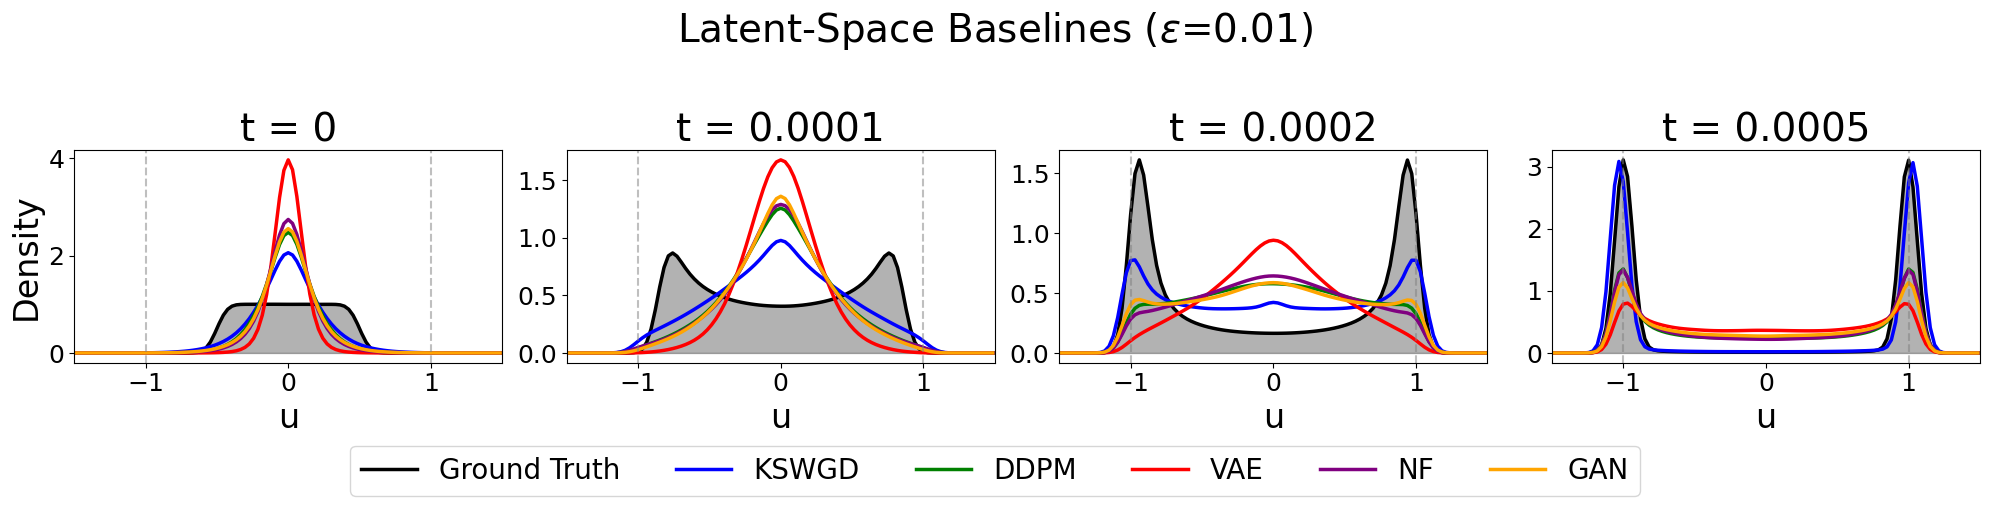

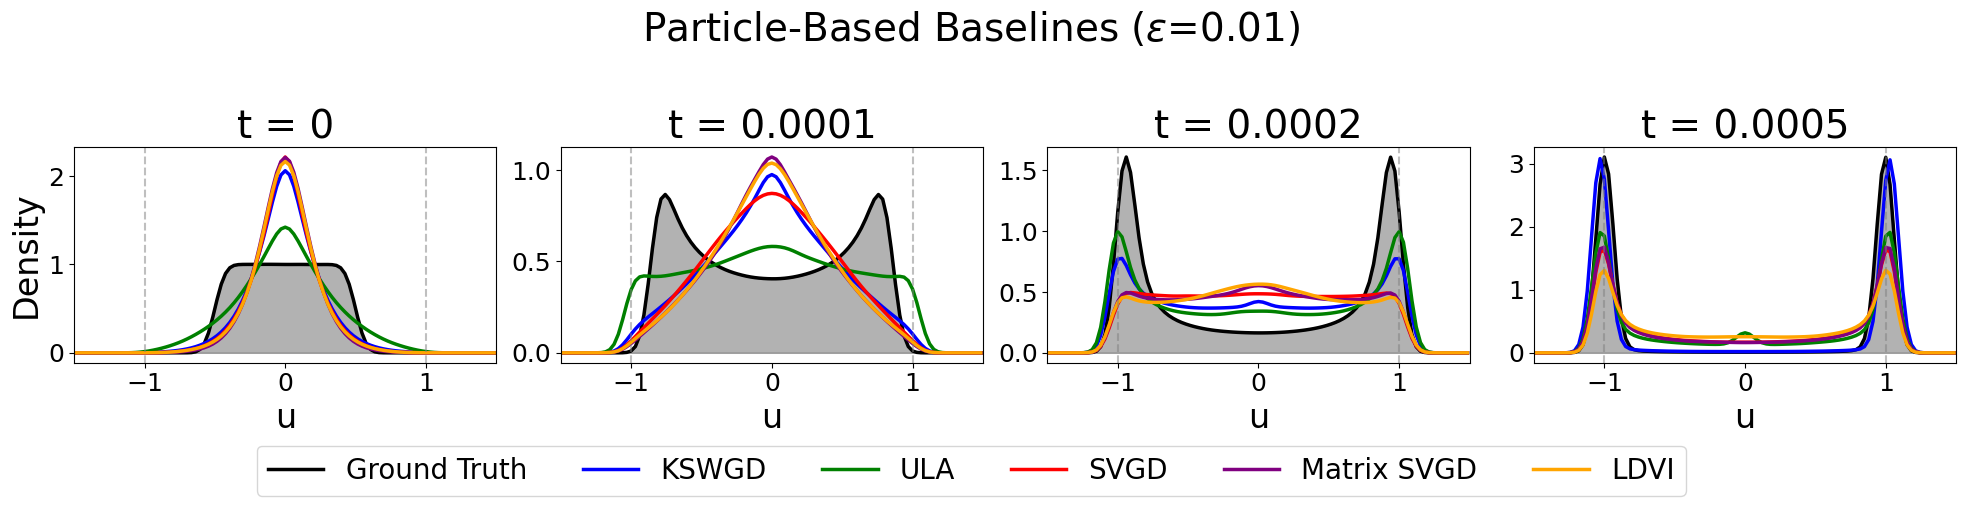

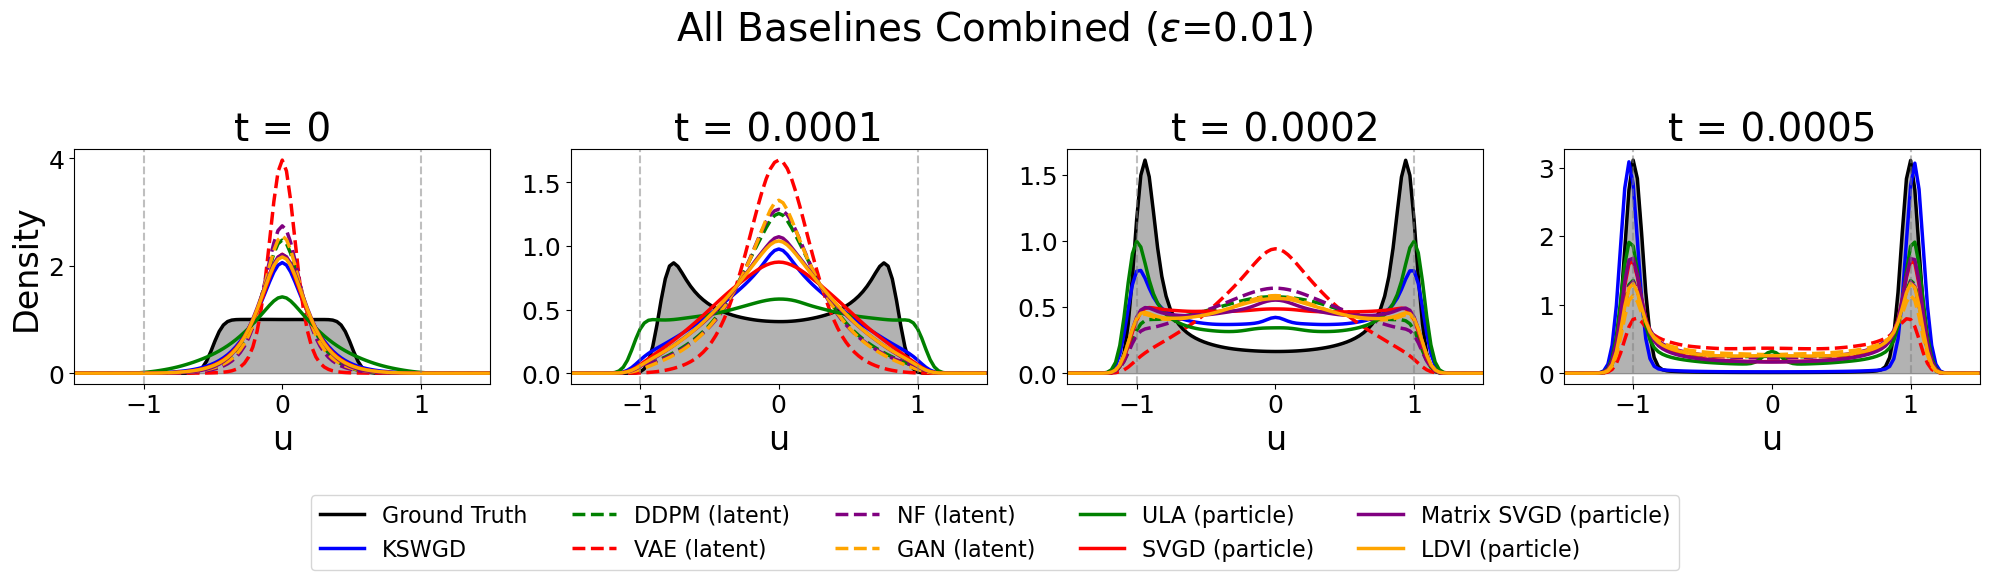

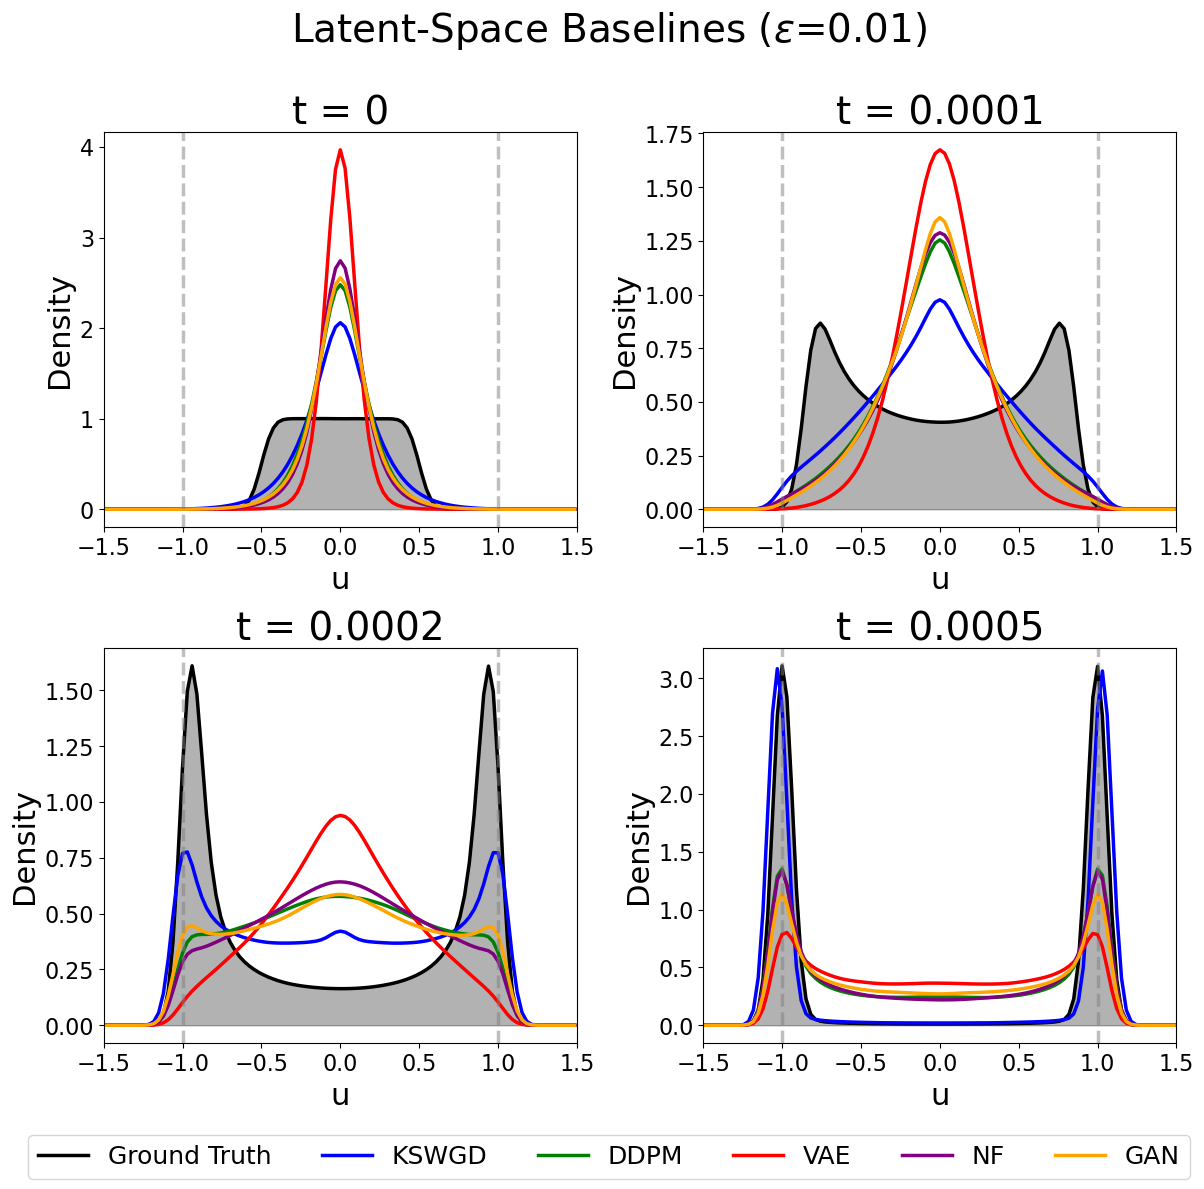

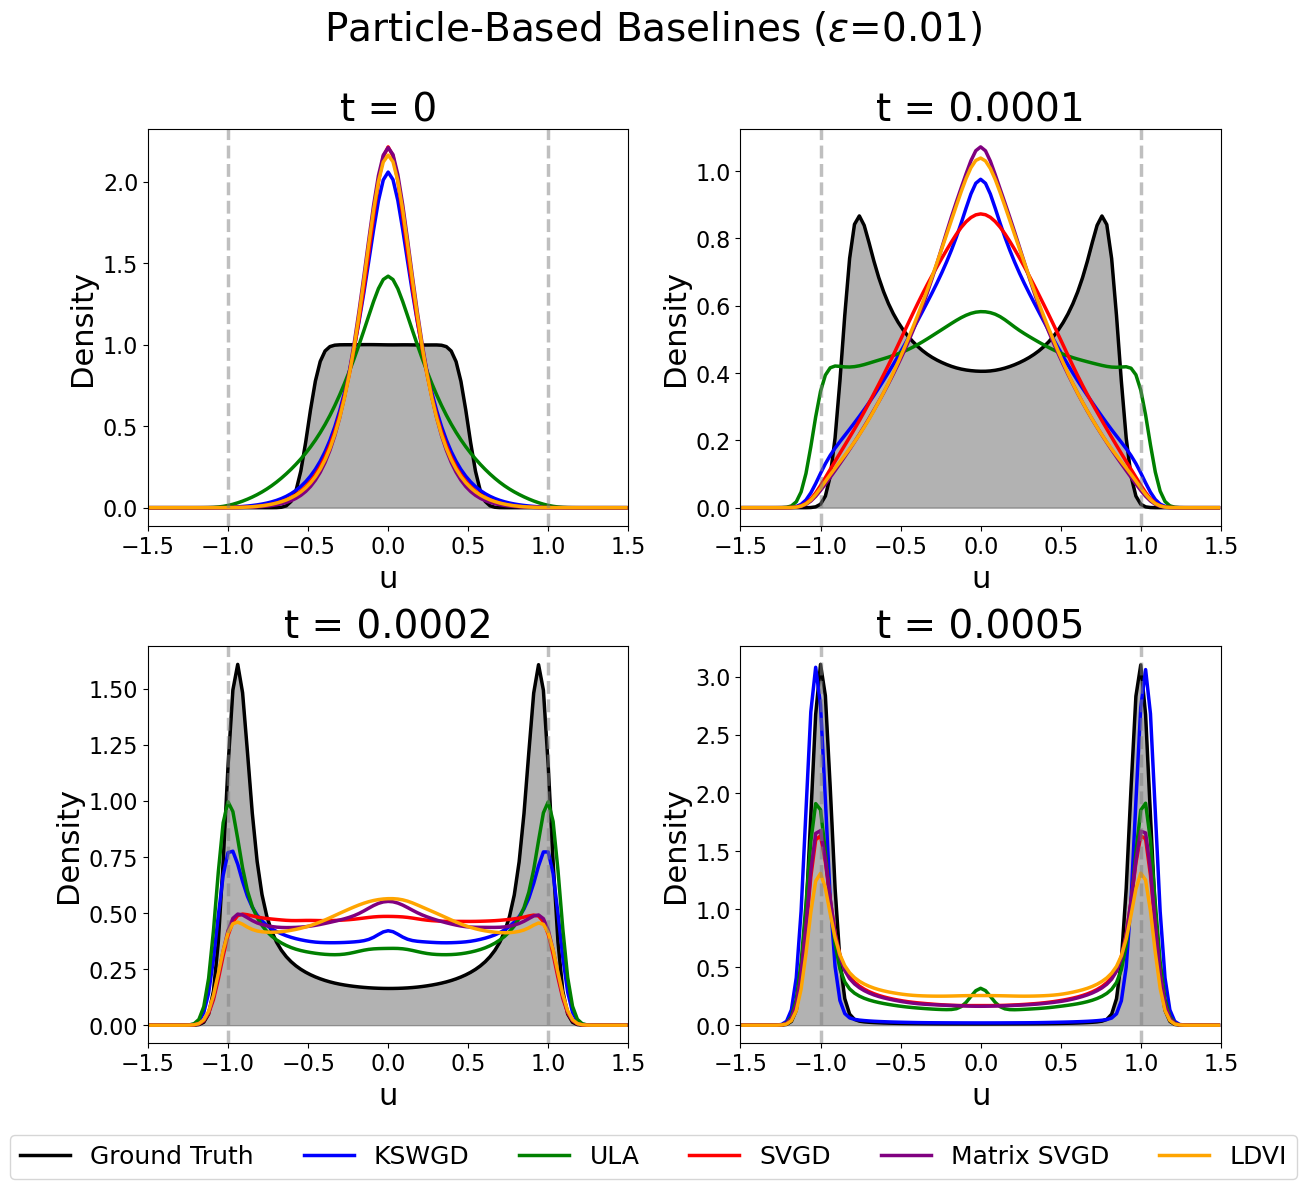

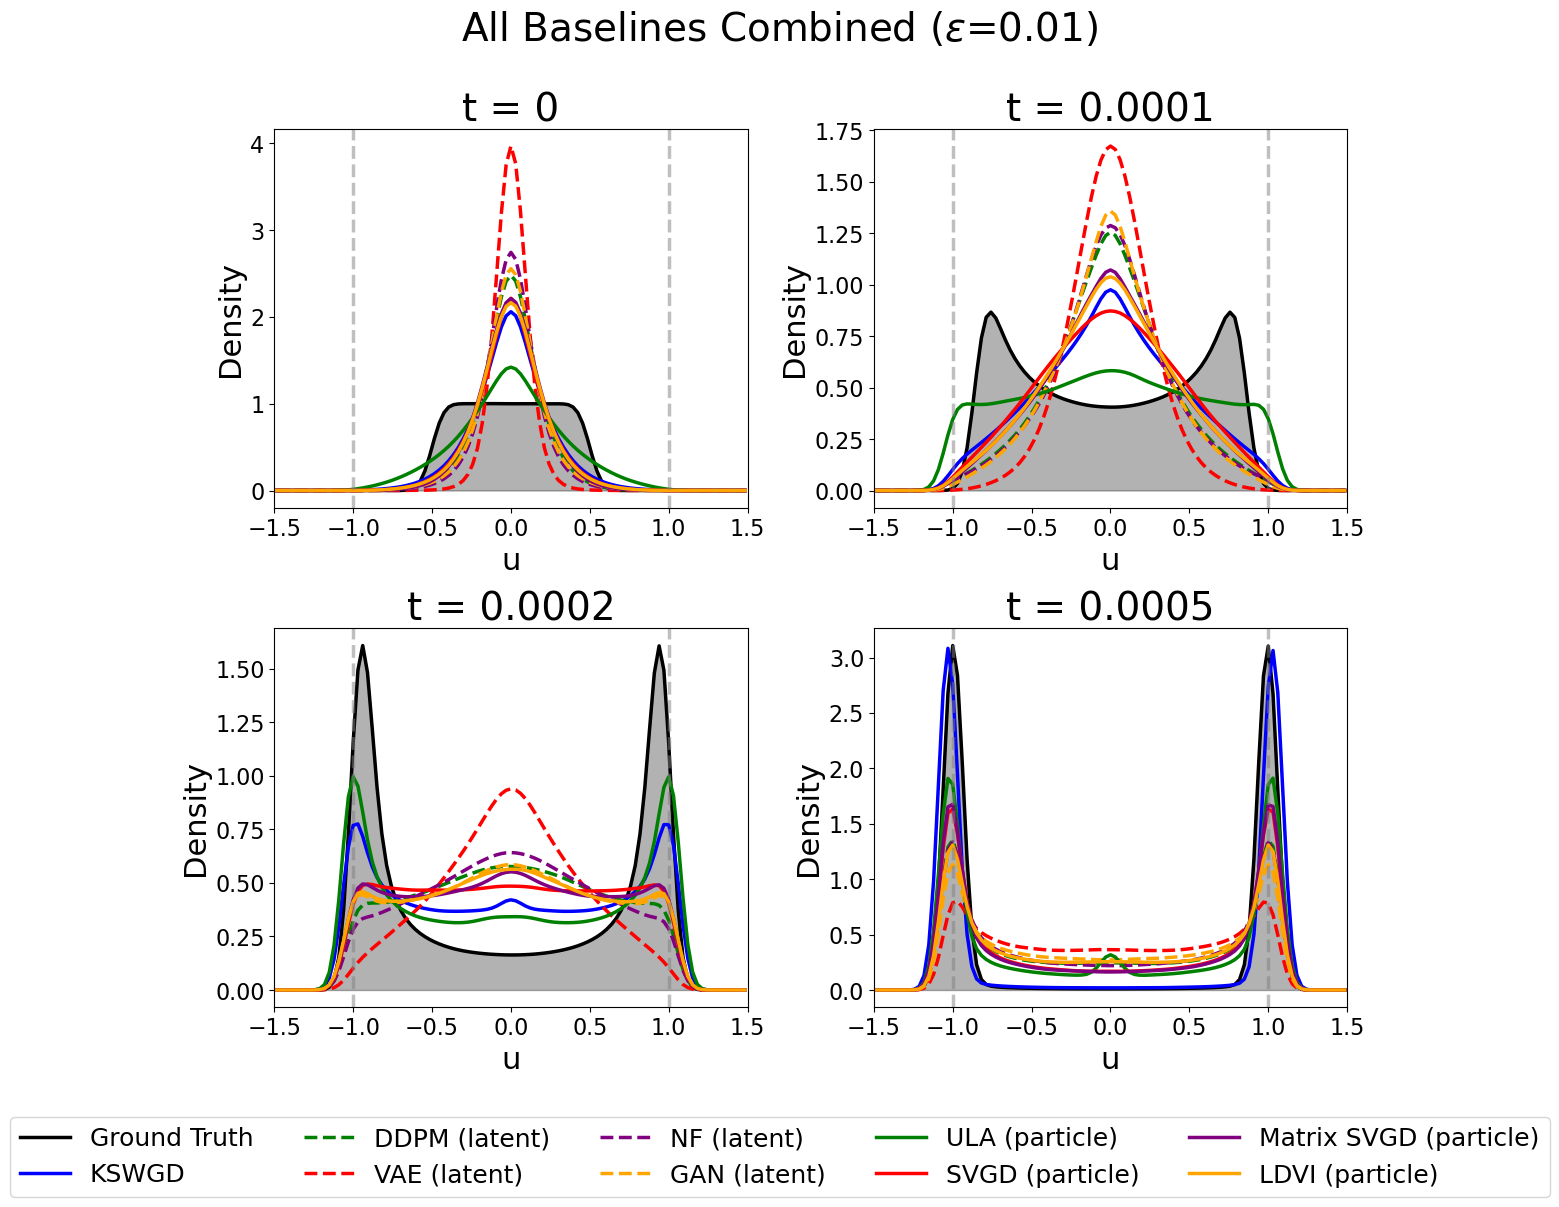

In [15]:
# === Combined Comparison Figures: Latent-Space vs Particle-Based Baselines ===
from scipy.ndimage import gaussian_filter1d

print("="*70)
print("COMBINED COMPARISON: Latent-Space vs Particle-Based Baselines")
print("="*70)

n_times = len(time_points)
bins = np.linspace(-1.5, 1.5, 100)
bin_centers = (bins[:-1] + bins[1:]) / 2
sigma = 2

def smooth_hist(values):
    return gaussian_filter1d(np.histogram(values, bins=bins, density=True)[0], sigma=sigma)

# ==================== Figure 1a: Latent-Space Baselines (1×4) ====================
fig_a, axes_a = plt.subplots(1, n_times, figsize=(5 * n_times, 5))

for col, t_phys in enumerate(time_points):
    kr = kswgd_time_results[t_phys]
    bl = baseline_results[t_phys]

    gt_s = smooth_hist(kr['ground_truth_samples'].flatten())
    ks_s = smooth_hist(kr['predicted_samples'].flatten())

    ax = axes_a[col]
    ax.fill_between(bin_centers, gt_s, alpha=0.3, color='black')
    ll1, = ax.plot(bin_centers, gt_s, 'k', lw=2.5)
    ll2, = ax.plot(bin_centers, ks_s, 'b', lw=2.5)
    ll3, = ax.plot(bin_centers, smooth_hist(bl['diffusion_samples'].flatten()), 'g', lw=2.5)
    ll4, = ax.plot(bin_centers, smooth_hist(bl['vae_samples'].flatten()), 'r', lw=2.5)
    ll5, = ax.plot(bin_centers, smooth_hist(bl['flow_samples'].flatten()), color='purple', lw=2.5)
    ll6, = ax.plot(bin_centers, smooth_hist(bl['gan_samples'].flatten()), color='orange', lw=2.5)
    ax.set_title(f't = {t_phys}', fontsize=28)
    ax.set_xlabel('u', fontsize=24)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(-1, color='gray', ls='--', alpha=0.5)
    ax.axvline(1, color='gray', ls='--', alpha=0.5)
    ax.tick_params(labelsize=18)
    if col == 0:
        ax.set_ylabel('Density', fontsize=24)

fig_a.suptitle(f'Latent-Space Baselines ($\\epsilon$={EPSILON_PDE})', fontsize=28)
fig_a.legend([ll1, ll2, ll3, ll4, ll5, ll6],
             ['Ground Truth', 'KSWGD', 'DDPM', 'VAE', 'NF', 'GAN'],
             loc='lower center', ncol=6, fontsize=20, frameon=True,
             bbox_to_anchor=(0.5, -0.02))
fig_a.tight_layout(rect=[0, 0.10, 1, 0.92])
plt.show()

# ==================== Figure 1b: Particle-Based Baselines (1×4) ====================
fig_b, axes_b = plt.subplots(1, n_times, figsize=(5 * n_times, 5))

for col, t_phys in enumerate(time_points):
    kr = kswgd_time_results[t_phys]
    pbl = particle_baseline_results[t_phys]

    gt_s = smooth_hist(kr['ground_truth_samples'].flatten())
    ks_s = smooth_hist(kr['predicted_samples'].flatten())

    ax2 = axes_b[col]
    ax2.fill_between(bin_centers, gt_s, alpha=0.3, color='black')
    lp1, = ax2.plot(bin_centers, gt_s, 'k', lw=2.5)
    lp2, = ax2.plot(bin_centers, ks_s, 'b', lw=2.5)
    lp3, = ax2.plot(bin_centers, smooth_hist(pbl['ula_samples'].flatten()), 'g', lw=2.5)
    lp4, = ax2.plot(bin_centers, smooth_hist(pbl['svgd_samples'].flatten()), 'r', lw=2.5)
    lp5, = ax2.plot(bin_centers, smooth_hist(pbl['matrix_svgd_samples'].flatten()), color='purple', lw=2.5)
    lp6, = ax2.plot(bin_centers, smooth_hist(pbl['ldvi_samples'].flatten()), color='orange', lw=2.5)
    ax2.set_title(f't = {t_phys}', fontsize=28)
    ax2.set_xlabel('u', fontsize=24)
    ax2.set_xlim(-1.5, 1.5)
    ax2.axvline(-1, color='gray', ls='--', alpha=0.5)
    ax2.axvline(1, color='gray', ls='--', alpha=0.5)
    ax2.tick_params(labelsize=18)
    if col == 0:
        ax2.set_ylabel('Density', fontsize=24)

fig_b.suptitle(f'Particle-Based Baselines ($\\epsilon$={EPSILON_PDE})', fontsize=28)
fig_b.legend([lp1, lp2, lp3, lp4, lp5, lp6],
             ['Ground Truth', 'KSWGD', 'ULA', 'SVGD', 'Matrix SVGD', 'LDVI'],
             loc='lower center', ncol=6, fontsize=20, frameon=True,
             bbox_to_anchor=(0.5, -0.02))
fig_b.tight_layout(rect=[0, 0.10, 1, 0.92])
plt.show()

# ==================== Figure 1c: Merged All Baselines (1×4) ====================
# Latent-space baselines: dashed lines; Particle-based baselines: solid lines
# Same colors reused: green, red, purple, orange
fig_c, axes_c = plt.subplots(1, n_times, figsize=(5 * n_times, 5.5))

for col, t_phys in enumerate(time_points):
    kr = kswgd_time_results[t_phys]
    bl = baseline_results[t_phys]
    pbl = particle_baseline_results[t_phys]

    gt_s = smooth_hist(kr['ground_truth_samples'].flatten())
    ks_s = smooth_hist(kr['predicted_samples'].flatten())

    ax = axes_c[col]
    ax.fill_between(bin_centers, gt_s, alpha=0.3, color='black')
    # Shared: GT and KSWGD (solid)
    mc1, = ax.plot(bin_centers, gt_s, 'k', lw=2.5)
    mc2, = ax.plot(bin_centers, ks_s, 'b', lw=2.5)
    # Latent-space baselines (dashed)
    mc3, = ax.plot(bin_centers, smooth_hist(bl['diffusion_samples'].flatten()), 'g', lw=2.5, ls='--')
    mc4, = ax.plot(bin_centers, smooth_hist(bl['vae_samples'].flatten()), 'r', lw=2.5, ls='--')
    mc5, = ax.plot(bin_centers, smooth_hist(bl['flow_samples'].flatten()), color='purple', lw=2.5, ls='--')
    mc6, = ax.plot(bin_centers, smooth_hist(bl['gan_samples'].flatten()), color='orange', lw=2.5, ls='--')
    # Particle-based baselines (solid)
    mc7, = ax.plot(bin_centers, smooth_hist(pbl['ula_samples'].flatten()), 'g', lw=2.5)
    mc8, = ax.plot(bin_centers, smooth_hist(pbl['svgd_samples'].flatten()), 'r', lw=2.5)
    mc9, = ax.plot(bin_centers, smooth_hist(pbl['matrix_svgd_samples'].flatten()), color='purple', lw=2.5)
    mc10, = ax.plot(bin_centers, smooth_hist(pbl['ldvi_samples'].flatten()), color='orange', lw=2.5)

    ax.set_title(f't = {t_phys}', fontsize=28)
    ax.set_xlabel('u', fontsize=24)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(-1, color='gray', ls='--', alpha=0.5)
    ax.axvline(1, color='gray', ls='--', alpha=0.5)
    ax.tick_params(labelsize=18)
    if col == 0:
        ax.set_ylabel('Density', fontsize=24)

fig_c.suptitle(f'All Baselines Combined ($\\epsilon$={EPSILON_PDE})', fontsize=28)
fig_c.legend([mc1, mc2, mc3, mc4, mc5, mc6, mc7, mc8, mc9, mc10],
             ['Ground Truth', 'KSWGD',
              'DDPM (latent)', 'VAE (latent)', 'NF (latent)', 'GAN (latent)',
              'ULA (particle)', 'SVGD (particle)', 'Matrix SVGD (particle)', 'LDVI (particle)'],
             loc='lower center', ncol=5, fontsize=16, frameon=True,
             bbox_to_anchor=(0.5, -0.06))
fig_c.tight_layout(rect=[0, 0.14, 1, 0.92])
plt.show()

# ==================== Figure 2a: Latent-Space Baselines (2×2) ====================
n_cols_2x2 = 2
n_rows_2x2 = (n_times + n_cols_2x2 - 1) // n_cols_2x2

fig2, axes2 = plt.subplots(n_rows_2x2, n_cols_2x2, figsize=(12, 6 * n_rows_2x2))
axes2 = axes2.flatten()

for idx, t_phys in enumerate(time_points):
    kr = kswgd_time_results[t_phys]
    bl = baseline_results[t_phys]

    gt_s = smooth_hist(kr['ground_truth_samples'].flatten())
    ks_s = smooth_hist(kr['predicted_samples'].flatten())

    ax = axes2[idx]
    ax.fill_between(bin_centers, gt_s, alpha=0.3, color='black')
    ll1, = ax.plot(bin_centers, gt_s, 'k', lw=PLOT_LINEWIDTH)
    ll2, = ax.plot(bin_centers, ks_s, 'b', lw=PLOT_LINEWIDTH)
    ll3, = ax.plot(bin_centers, smooth_hist(bl['diffusion_samples'].flatten()), 'g', lw=PLOT_LINEWIDTH)
    ll4, = ax.plot(bin_centers, smooth_hist(bl['vae_samples'].flatten()), 'r', lw=PLOT_LINEWIDTH)
    ll5, = ax.plot(bin_centers, smooth_hist(bl['flow_samples'].flatten()), color='purple', lw=PLOT_LINEWIDTH)
    ll6, = ax.plot(bin_centers, smooth_hist(bl['gan_samples'].flatten()), color='orange', lw=PLOT_LINEWIDTH)
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_title(f't = {t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(-1, color='gray', ls='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(1, color='gray', ls='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)

for idx in range(n_times, len(axes2)):
    axes2[idx].axis('off')

fig2.legend([ll1, ll2, ll3, ll4, ll5, ll6],
            ['Ground Truth', 'KSWGD', 'DDPM', 'VAE', 'NF', 'GAN'],
            loc='lower center', ncol=6, fontsize=PLOT_LEGEND_FONTSIZE_GRID, frameon=True,
            bbox_to_anchor=(0.5, -0.005))
fig2.suptitle(f'Latent-Space Baselines ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
fig2.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

# ==================== Figure 2b: Particle-Based Baselines (2×2) ====================
fig3, axes3 = plt.subplots(n_rows_2x2, n_cols_2x2, figsize=(12, 6 * n_rows_2x2))
axes3 = axes3.flatten()

for idx, t_phys in enumerate(time_points):
    kr = kswgd_time_results[t_phys]
    pbl = particle_baseline_results[t_phys]

    gt_s = smooth_hist(kr['ground_truth_samples'].flatten())
    ks_s = smooth_hist(kr['predicted_samples'].flatten())

    ax = axes3[idx]
    ax.fill_between(bin_centers, gt_s, alpha=0.3, color='black')
    lp1, = ax.plot(bin_centers, gt_s, 'k', lw=PLOT_LINEWIDTH)
    lp2, = ax.plot(bin_centers, ks_s, 'b', lw=PLOT_LINEWIDTH)
    lp3, = ax.plot(bin_centers, smooth_hist(pbl['ula_samples'].flatten()), 'g', lw=PLOT_LINEWIDTH)
    lp4, = ax.plot(bin_centers, smooth_hist(pbl['svgd_samples'].flatten()), 'r', lw=PLOT_LINEWIDTH)
    lp5, = ax.plot(bin_centers, smooth_hist(pbl['matrix_svgd_samples'].flatten()), color='purple', lw=PLOT_LINEWIDTH)
    lp6, = ax.plot(bin_centers, smooth_hist(pbl['ldvi_samples'].flatten()), color='orange', lw=PLOT_LINEWIDTH)
    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_title(f't = {t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(-1, color='gray', ls='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(1, color='gray', ls='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)

for idx in range(n_times, len(axes3)):
    axes3[idx].axis('off')

fig3.legend([lp1, lp2, lp3, lp4, lp5, lp6],
            ['Ground Truth', 'KSWGD', 'ULA', 'SVGD', 'Matrix SVGD', 'LDVI'],
            loc='lower center', ncol=6, fontsize=PLOT_LEGEND_FONTSIZE_GRID, frameon=True,
            bbox_to_anchor=(0.5, -0.005))
fig3.suptitle(f'Particle-Based Baselines ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
fig3.tight_layout(rect=[0, 0.05, 1, 0.97])
plt.show()

# ==================== Figure 2c: Merged All Baselines (2×2) ====================
# Latent-space baselines: dashed lines; Particle-based baselines: solid lines
fig4, axes4 = plt.subplots(n_rows_2x2, n_cols_2x2, figsize=(12, 6 * n_rows_2x2))
axes4 = axes4.flatten()

for idx, t_phys in enumerate(time_points):
    kr = kswgd_time_results[t_phys]
    bl = baseline_results[t_phys]
    pbl = particle_baseline_results[t_phys]

    gt_s = smooth_hist(kr['ground_truth_samples'].flatten())
    ks_s = smooth_hist(kr['predicted_samples'].flatten())

    ax = axes4[idx]
    ax.fill_between(bin_centers, gt_s, alpha=0.3, color='black')
    # Shared: GT and KSWGD (solid)
    mg1, = ax.plot(bin_centers, gt_s, 'k', lw=PLOT_LINEWIDTH)
    mg2, = ax.plot(bin_centers, ks_s, 'b', lw=PLOT_LINEWIDTH)
    # Latent-space baselines (dashed)
    mg3, = ax.plot(bin_centers, smooth_hist(bl['diffusion_samples'].flatten()), 'g', lw=PLOT_LINEWIDTH, ls='--')
    mg4, = ax.plot(bin_centers, smooth_hist(bl['vae_samples'].flatten()), 'r', lw=PLOT_LINEWIDTH, ls='--')
    mg5, = ax.plot(bin_centers, smooth_hist(bl['flow_samples'].flatten()), color='purple', lw=PLOT_LINEWIDTH, ls='--')
    mg6, = ax.plot(bin_centers, smooth_hist(bl['gan_samples'].flatten()), color='orange', lw=PLOT_LINEWIDTH, ls='--')
    # Particle-based baselines (solid)
    mg7, = ax.plot(bin_centers, smooth_hist(pbl['ula_samples'].flatten()), 'g', lw=PLOT_LINEWIDTH)
    mg8, = ax.plot(bin_centers, smooth_hist(pbl['svgd_samples'].flatten()), 'r', lw=PLOT_LINEWIDTH)
    mg9, = ax.plot(bin_centers, smooth_hist(pbl['matrix_svgd_samples'].flatten()), color='purple', lw=PLOT_LINEWIDTH)
    mg10, = ax.plot(bin_centers, smooth_hist(pbl['ldvi_samples'].flatten()), color='orange', lw=PLOT_LINEWIDTH)

    ax.set_xlabel('u', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_ylabel('Density', fontsize=PLOT_LABEL_FONTSIZE_GRID)
    ax.set_title(f't = {t_phys}', fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlim(-1.5, 1.5)
    ax.axvline(-1, color='gray', ls='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.axvline(1, color='gray', ls='--', alpha=0.5, linewidth=PLOT_LINEWIDTH)
    ax.tick_params(labelsize=PLOT_TICK_FONTSIZE_GRID)

for idx in range(n_times, len(axes4)):
    axes4[idx].axis('off')

fig4.legend([mg1, mg2, mg3, mg4, mg5, mg6, mg7, mg8, mg9, mg10],
            ['Ground Truth', 'KSWGD',
             'DDPM (latent)', 'VAE (latent)', 'NF (latent)', 'GAN (latent)',
             'ULA (particle)', 'SVGD (particle)', 'Matrix SVGD (particle)', 'LDVI (particle)'],
            loc='lower center', ncol=5, fontsize=PLOT_LEGEND_FONTSIZE_GRID, frameon=True,
            bbox_to_anchor=(0.5, -0.02))
fig4.suptitle(f'All Baselines Combined ($\\epsilon$={EPSILON_PDE})', fontsize=PLOT_TITLE_FONTSIZE)
fig4.tight_layout(rect=[0, 0.08, 1, 0.97])
plt.show()